In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                            accuracy_score, precision_score, recall_score,
                            f1_score, roc_auc_score, roc_curve)
import lightgbm as lgb
import warnings
from datetime import datetime
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Tahoma', 'DejaVu Sans', 'Liberation Sans']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
from datetime import datetime, timedelta
from scipy import stats
import itertools

plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = ['#FF6B35', '#004E89', '#1A936F', '#C84B31', '#88D498', '#F3A712']
sns.set_palette(PALETTE)
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', 50)

In [3]:
companies = pd.read_csv('/content/companies.csv')
jobs = pd.read_csv('/content/jobs.csv')
job_levels = pd.read_csv('/content/job_levels.csv')
job_skills = pd.read_csv('/content/job_skills.csv')
levels = pd.read_csv('/content/levels.csv')
skills = pd.read_csv('/content/skills.csv')
roles = pd.read_csv('/content/roles.csv')
role_skills = pd.read_csv('/content/role_skills.csv')
locations = pd.read_csv('/content/locations.csv')


In [4]:
import pandas as pd

# Đọc các bảng dữ liệu
jobs = pd.read_csv('jobs.csv')
companies = pd.read_csv('companies.csv')
roles = pd.read_csv('roles.csv')
levels = pd.read_csv('levels.csv')
locations = pd.read_csv('locations.csv')
job_skills = pd.read_csv('job_skills.csv')
skills = pd.read_csv('skills.csv')

# Đổi tên cột id của các bảng tham chiếu thành tên cột tương ứng trong bảng jobs để dễ gộp
companies = companies.rename(columns={'id': 'company_id', 'name': 'company_name'})
roles = roles.rename(columns={'id': 'role_id', 'name': 'role_name'})
levels = levels.rename(columns={'id': 'level_id', 'name': 'level_name'})
locations = locations.rename(columns={'id': 'location_id'})
skills = skills.rename(columns={'id': 'skill_id', 'name': 'skill_name'})

# Bắt đầu gộp các bảng với bảng thông tin công việc (jobs)
df = jobs.copy()

# Gộp với bảng công ty
df = df.merge(companies, on='company_id', how='left')

# Gộp với bảng vị trí công việc (role)
df = df.merge(roles, on='role_id', how='left')

# Gộp với bảng cấp bậc (level)
df = df.merge(levels, on='level_id', how='left')

# Gộp với bảng địa điểm (location)
df = df.merge(locations, on='location_id', how='left')

print("\nKích thước bảng ban đầu:", jobs.shape)
print("Kích thước bảng sau khi gộp thông tin cơ bản:", df.shape)

# Tùy chọn: Gộp thêm thông tin kỹ năng (skills)
# Lưu ý: Vì 1 công việc thường yêu cầu nhiều kỹ năng, việc gộp bảng kỹ năng
# sẽ làm bảng dữ liệu sinh ra nhiều dòng trùng lặp cho cùng 1 công việc.
df_with_skills = df.merge(job_skills[['job_id', 'skill_id']], left_on='id', right_on='job_id', how='left')
df_with_skills = df_with_skills.merge(skills, on='skill_id', how='left')

print("Kích thước bảng sau khi gộp thêm thông tin kỹ năng:", df_with_skills.shape)
import pandas as pd

# Giả sử 'df' là bảng dữ liệu đã được gộp từ các bước trước

# 4. Chuyển các cột ngày tháng trong bảng jobs sang kiểu datetime
date_columns = [
    'posted_at', 'created_at'
]

for col in date_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

# 5. Kiểm tra giá trị bị thiếu (hiển thị 20 cột có nhiều giá trị thiếu nhất)
print("\nThống kê giá trị thiếu (20 cột nhiều nhất):")
print(df.isnull().sum().sort_values(ascending=False).head(20))

# 6. Tạo file data đầy đủ
df.to_csv('/content/merged_jobs_full.csv', encoding='utf-8', index=False)
print("\nĐã lưu bảng dữ liệu gộp đầy đủ: /content/merged_jobs_full.csv")

# 7. Chọn các cột quan trọng để tạo phiên bản nhẹ (df_light)
key_columns = [
    'id', 'title', 'company_name', 'role_name', 'level_name',
    'city', 'country', 'salary_min', 'salary_max', 'exp_min', 'exp_max',
    'source', 'url', 'posted_at'
]

# Lọc ra những cột thực sự tồn tại trong df để tránh lỗi (đề phòng bạn thay đổi cách gộp)
existing_key_columns = [col for col in key_columns if col in df.columns]

df_light = df[existing_key_columns]
df_light.to_csv('/content/jobs_light.csv', encoding='utf-8', index=False)
print("Đã lưu phiên bản nhẹ: /content/jobs_light.csv")


Kích thước bảng ban đầu: (8929, 16)
Kích thước bảng sau khi gộp thông tin cơ bản: (8929, 21)
Kích thước bảng sau khi gộp thêm thông tin kỹ năng: (28726, 24)

Thống kê giá trị thiếu (20 cột nhiều nhất):
level_id        7903
level_name      7903
exp_min         6292
salary_max      5702
salary_min      5612
exp_max         1684
role_name        354
role_id          354
posted_at          6
title              0
company_id         0
id                 0
location_id        0
raw_data           0
source             0
url                0
created_at         0
company_name       0
is_active          0
city               0
dtype: int64

Đã lưu bảng dữ liệu gộp đầy đủ: /content/merged_jobs_full.csv
Đã lưu phiên bản nhẹ: /content/jobs_light.csv


In [5]:
merged_jobs_full = pd.read_csv('/content/merged_jobs_full.csv')
print(merged_jobs_full.head())

     id                                              title  company_id  \
0  2266                                     Kế Toán Trưởng        1379   
1  2265                 Chuyên Viên Kinh DoanhPhần Mềm B2B         618   
2  4976                               Full Stack Developer        2707   
3  5109              Full-stack Developer (NodeJS, Python)        2676   
4  5530  Senior Fullstack Developer (ReactJS & Java) - ...        2951   

   role_id  level_id  location_id  salary_min  salary_max  exp_min  exp_max  \
0    11.00       NaN            1         NaN         NaN      NaN     5.00   
1     1.00       NaN            2         NaN         NaN      NaN     2.00   
2     3.00       NaN            2         NaN         NaN     2.00     2.00   
3     3.00       NaN            1         NaN         NaN     3.00     3.00   
4     3.00       NaN            2         NaN         NaN     6.00     6.00   

                                                 url  source  \
0  https://www.t

In [6]:
merged_jobs_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8929 entries, 0 to 8928
Data columns (total 21 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            8929 non-null   int64  
 1   title         8929 non-null   object 
 2   company_id    8929 non-null   int64  
 3   role_id       8575 non-null   float64
 4   level_id      1026 non-null   float64
 5   location_id   8929 non-null   int64  
 6   salary_min    3317 non-null   float64
 7   salary_max    3227 non-null   float64
 8   exp_min       2637 non-null   float64
 9   exp_max       7245 non-null   float64
 10  url           8929 non-null   object 
 11  source        8929 non-null   object 
 12  raw_data      8929 non-null   object 
 13  posted_at     8923 non-null   object 
 14  created_at    8929 non-null   object 
 15  is_active     8929 non-null   bool   
 16  company_name  8929 non-null   object 
 17  role_name     8575 non-null   object 
 18  level_name    1026 non-null 

In [7]:
merged_jobs_full.describe()

,id,company_id,role_id,level_id,location_id,salary_min,salary_max,exp_min,exp_max
count,8929.00,8929.00,8575.00,1026.00,8929.00,3317.00,3227.00,2637.00,7245.00
mean,5246.61,1661.36,13.56,2.14,2.64,20417566.15,31058627.99,13.95,40.34
std,3182.42,1120.38,9.15,1.45,6.16,30850162.52,54147055.48,511.87,1148.49
min,1.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00
25%,2518.00,662.00,4.00,1.00,1.00,10000000.00,15000000.00,1.00,1.00
50%,5074.00,1477.00,15.00,2.00,1.00,15000000.00,20000000.00,3.00,2.00
75%,8000.00,2662.00,21.00,2.00,2.00,22000000.00,35000000.00,4.00,3.00
max,11616.00,3870.00,40.00,7.00,66.00,850000000.00,850000000.00,26262.00,60000.00


In [8]:
class JobDataPreprocessor:
    """Lớp thực hiện tiền xử lý dữ liệu tuyển dụng"""

    def __init__(self, filepath):
        """Khởi tạo với đường dẫn file"""
        self.filepath = filepath
        self.df = None
        self.df_processed = None
        self.scaler = StandardScaler()
        self.label_encoders = {}

    def load_data(self):
        """Bước 1: Đọc và kiểm tra dữ liệu ban đầu"""
        print("=" * 80)
        print("BƯỚC 1: KIỂM TRA DỮ LIỆU BAN ĐẦU")
        print("=" * 80)

        self.df = pd.read_csv(self.filepath)
        print(f"\n✓ Đọc dữ liệu thành công!")
        print(f"  - Số dòng: {len(self.df):,}")
        print(f"  - Số cột: {len(self.df.columns)}")
        print(f"  - Kích thước bộ nhớ: {self.df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

        # Hiển thị thông tin cơ bản
        print(f"\n📊 Kiểu dữ liệu:")
        print(self.df.dtypes.value_counts())

        print(f"\n📋 Mẫu dữ liệu:")
        print(self.df.head(3))

        return self

In [9]:
def analyze_missing_values(self):
        missing_stats = pd.DataFrame({
            'Cột': self.df.columns,
            'Số lượng thiếu': self.df.isnull().sum().values,
            'Tỷ lệ (%)': (self.df.isnull().sum() / len(self.df) * 100).round(2).values
        })

        missing_stats = missing_stats[missing_stats['Số lượng thiếu'] > 0].sort_values(
            'Tỷ lệ (%)', ascending=False
        )

        if len(missing_stats) > 0:
            print(f"\n⚠️  Phát hiện {len(missing_stats)} cột có giá trị thiếu:")
            print(missing_stats.to_string(index=False))
        else:
            print("\n✓ Không có giá trị thiếu!")

        return self
def handle_missing_values(self):
        """Xử lý giá trị thiếu"""
        print("\n🔧 Xử lý giá trị thiếu...")

        self.df_processed = self.df.copy()

        # Xóa các cột có quá nhiều giá trị thiếu (>70%)
        high_missing_cols = ['role_id', 'role_name']
        self.df_processed = self.df_processed.drop(columns=high_missing_cols, errors='ignore')
        print(f"  - Xóa {len(high_missing_cols)} cột có >70% giá trị thiếu")

        # Điền giá trị thiếu cho exp_min
        if 'exp_min' in self.df_processed.columns:
            median_exp = self.df_processed['exp_min'].median()
            filled_exp = self.df_processed['exp_min'].isnull().sum()
            self.df_processed['exp_min'].fillna(median_exp, inplace=True)
            print(f"  - Điền {filled_exp} giá trị exp_min bằng median ({median_exp})")

        # Điền giá trị thiếu cho exp_max
        if 'exp_max' in self.df_processed.columns:
            # Điền bằng exp_min + 2
            mask = self.df_processed['exp_max'].isnull()
            filled_count = mask.sum()
            self.df_processed.loc[mask, 'exp_max'] = self.df_processed.loc[mask, 'exp_min'] + 2
            print(f"  - Điền {filled_count} giá trị exp_max = exp_min + 2")

        # Điền giá trị thiếu cho salary
        for col in ['salary_min', 'salary_max']:
            if col in self.df_processed.columns:
                median_val = self.df_processed[col].median()
                filled_count = self.df_processed[col].isnull().sum()
                self.df_processed[col].fillna(median_val, inplace=True)
                print(f"  - Điền {filled_count} giá trị {col} bằng median ({median_val:,.0f})")

        # Điền giá trị thiếu cho level_id và level_name
        if 'level_name' in self.df_processed.columns:
            filled_count = self.df_processed['level_name'].isnull().sum()
            self.df_processed['level_name'].fillna('Unknown', inplace=True)
            print(f"  - Điền {filled_count} giá trị level_name = 'Unknown'")

        # Điền giá trị thiếu cho location
        for col in ['city', 'country', 'location_id']:
            if col in self.df_processed.columns and self.df_processed[col].isnull().sum() > 0:
                if col == 'country':
                    self.df_processed[col].fillna('Vietnam', inplace=True)
                elif col == 'city':
                    self.df_processed[col].fillna('Unknown', inplace=True)
                else:
                    self.df_processed[col].fillna(0, inplace=True)

        # Điền posted_at với giá trị mặc định
        if 'posted_at' in self.df_processed.columns:
            filled_count = self.df_processed['posted_at'].isnull().sum()
            self.df_processed['posted_at'].fillna('Unknown', inplace=True)
            print(f"  - Điền {filled_count} giá trị posted_at = 'Unknown'")

        print(f"\n✓ Hoàn thành xử lý giá trị thiếu!")

        return self

In [10]:
    def remove_duplicates(self):
        initial_rows = len(self.df_processed)

        # Loại bỏ trùng lặp hoàn toàn
        self.df_processed = self.df_processed.drop_duplicates()
        complete_dups = initial_rows - len(self.df_processed)
        print(f"\n  - Xóa {complete_dups} dòng trùng lặp hoàn toàn")

        # Loại bỏ trùng lặp theo URL (giữ lại dòng đầu tiên)
        if 'url' in self.df_processed.columns:
            before = len(self.df_processed)
            self.df_processed = self.df_processed.drop_duplicates(subset=['url'], keep='first')
            url_dups = before - len(self.df_processed)
            print(f"  - Xóa {url_dups} dòng trùng lặp theo URL")

        # Loại bỏ trùng lặp theo title + company_id
        if 'title' in self.df_processed.columns and 'company_id' in self.df_processed.columns:
            before = len(self.df_processed)
            self.df_processed = self.df_processed.drop_duplicates(
                subset=['title', 'company_id'], keep='first'
            )
            title_dups = before - len(self.df_processed)
            print(f"  - Xóa {title_dups} dòng trùng lặp theo Title + Company")

        total_removed = initial_rows - len(self.df_processed)
        print(f"\n✓ Tổng cộng xóa {total_removed} dòng trùng lặp")
        print(f"  Còn lại: {len(self.df_processed):,} dòng")

        return self

    def handle_outliers(self):
        numeric_cols = ['salary_min', 'salary_max', 'exp_min', 'exp_max']

        for col in numeric_cols:
            if col in self.df_processed.columns:
                # Tính IQR
                Q1 = self.df_processed[col].quantile(0.25)
                Q3 = self.df_processed[col].quantile(0.75)
                IQR = Q3 - Q1

                lower_bound = Q1 - 1.5 * IQR
                upper_bound = Q3 + 1.5 * IQR

                # Đếm ngoại lai
                outliers_mask = (self.df_processed[col] < lower_bound) | (self.df_processed[col] > upper_bound)
                n_outliers = outliers_mask.sum()

                print(f"\n📊 {col}:")
                print(f"  - Phát hiện {n_outliers} ngoại lai ({n_outliers/len(self.df_processed)*100:.2f}%)")
                print(f"  - Ngưỡng: [{lower_bound:,.0f}, {upper_bound:,.0f}]")

                # Xử lý: Cap giá trị ngoại lai
                if n_outliers > 0:
                    self.df_processed.loc[self.df_processed[col] < lower_bound, col] = lower_bound
                    self.df_processed.loc[self.df_processed[col] > upper_bound, col] = upper_bound
                    print(f"  ✓ Đã cap các giá trị ngoại lai")

        # Xử lý logic nghiệp vụ
        print("\n🔍 Kiểm tra logic nghiệp vụ:")

        # salary_max phải >= salary_min
        if 'salary_min' in self.df_processed.columns and 'salary_max' in self.df_processed.columns:
            invalid_salary = (self.df_processed['salary_max'] < self.df_processed['salary_min'])
            if invalid_salary.sum() > 0:
                print(f"  - Sửa {invalid_salary.sum()} dòng có salary_max < salary_min")
                # Hoán đổi giá trị
                temp = self.df_processed.loc[invalid_salary, 'salary_min'].copy()
                self.df_processed.loc[invalid_salary, 'salary_min'] = self.df_processed.loc[invalid_salary, 'salary_max']
                self.df_processed.loc[invalid_salary, 'salary_max'] = temp

        # exp_max phải >= exp_min
        if 'exp_min' in self.df_processed.columns and 'exp_max' in self.df_processed.columns:
            invalid_exp = (self.df_processed['exp_max'] < self.df_processed['exp_min'])
            if invalid_exp.sum() > 0:
                print(f"  - Sửa {invalid_exp.sum()} dòng có exp_max < exp_min")
                temp = self.df_processed.loc[invalid_exp, 'exp_min'].copy()
                self.df_processed.loc[invalid_exp, 'exp_min'] = self.df_processed.loc[invalid_exp, 'exp_max']
                self.df_processed.loc[invalid_exp, 'exp_max'] = temp

        print("\n✓ Hoàn thành xử lý ngoại lai!")

        return self

In [11]:
def normalize_data(self):
        # Chuẩn hóa text
        print("\n📝 Chuẩn hóa dữ liệu text:")
        text_cols = ['title', 'company_name', 'level_name', 'city', 'source']

        for col in text_cols:
            if col in self.df_processed.columns:
                # Loại bỏ khoảng trắng thừa
                self.df_processed[col] = self.df_processed[col].astype(str).str.strip()
                # Chuẩn hóa về lowercase cho một số cột
                if col in ['source']:
                    self.df_processed[col] = self.df_processed[col].str.lower()
                print(f"  ✓ {col}")

        # Tạo các đặc trưng mới
        print("\n🆕 Tạo đặc trưng mới:")

        # Tính mức lương trung bình
        if 'salary_min' in self.df_processed.columns and 'salary_max' in self.df_processed.columns:
            self.df_processed['salary_avg'] = (
                self.df_processed['salary_min'] + self.df_processed['salary_max']
            ) / 2
            print("  ✓ salary_avg = (salary_min + salary_max) / 2")

        # Tính khoảng lương
        if 'salary_min' in self.df_processed.columns and 'salary_max' in self.df_processed.columns:
            self.df_processed['salary_range'] = (
                self.df_processed['salary_max'] - self.df_processed['salary_min']
            )
            print("  ✓ salary_range = salary_max - salary_min")

        # Tính kinh nghiệm trung bình
        if 'exp_min' in self.df_processed.columns and 'exp_max' in self.df_processed.columns:
            self.df_processed['exp_avg'] = (
                self.df_processed['exp_min'] + self.df_processed['exp_max']
            ) / 2
            print("  ✓ exp_avg = (exp_min + exp_max) / 2")

        # Độ dài title
        if 'title' in self.df_processed.columns:
            self.df_processed['title_length'] = self.df_processed['title'].str.len()
            print("  ✓ title_length = độ dài tiêu đề")

        # Số từ trong title
        if 'title' in self.df_processed.columns:
            self.df_processed['title_word_count'] = self.df_processed['title'].str.split().str.len()
            print("  ✓ title_word_count = số từ trong tiêu đề")

        # Phân nhóm mức lương
        if 'salary_avg' in self.df_processed.columns:
            self.df_processed['salary_category'] = pd.cut(
                self.df_processed['salary_avg'],
                bins=[0, 10_000_000, 20_000_000, 30_000_000, float('inf')],
                labels=['Dưới 10tr', '10-20tr', '20-30tr', 'Trên 30tr']
            )
            print("  ✓ salary_category = phân nhóm mức lương")

        # Phân nhóm kinh nghiệm
        if 'exp_avg' in self.df_processed.columns:
            self.df_processed['exp_category'] = pd.cut(
                self.df_processed['exp_avg'],
                bins=[0, 1, 3, 5, float('inf')],
                labels=['Fresher', 'Junior', 'Mid', 'Senior+']
            )
            print("  ✓ exp_category = phân nhóm kinh nghiệm")

        # Chuẩn hóa (Standardization) các cột số
        print("\n📐 Chuẩn hóa (Standardization) các cột số:")
        numeric_cols_to_scale = ['salary_min', 'salary_max', 'salary_avg', 'exp_min', 'exp_max', 'exp_avg']

        cols_to_scale = [col for col in numeric_cols_to_scale if col in self.df_processed.columns]

        if len(cols_to_scale) > 0:
            # Tạo các cột đã chuẩn hóa
            scaled_data = self.scaler.fit_transform(self.df_processed[cols_to_scale])
            scaled_df = pd.DataFrame(
                scaled_data,
                columns=[f'{col}_scaled' for col in cols_to_scale],
                index=self.df_processed.index
            )
            self.df_processed = pd.concat([self.df_processed, scaled_df], axis=1)
            print(f"  ✓ Đã chuẩn hóa {len(cols_to_scale)} cột (mean=0, std=1)")
            for col in cols_to_scale:
                print(f"    - {col}_scaled")

        print("\n✓ Hoàn thành chuẩn hóa dữ liệu!")

        return self


In [12]:
 def encode_categorical(self):
        """Bước 6: Mã hóa biến phân loại"""
        print("\n" + "=" * 80)
        print("BƯỚC 6: MÃ HÓA BIẾN PHÂN LOẠI")
        print("=" * 80)

        # Label Encoding cho các cột có thứ tự
        print("\n🏷️  Label Encoding:")
        ordinal_cols = ['level_name']

        for col in ordinal_cols:
            if col in self.df_processed.columns:
                le = LabelEncoder()
                self.df_processed[f'{col}_encoded'] = le.fit_transform(
                    self.df_processed[col].astype(str)
                )
                self.label_encoders[col] = le
                print(f"  ✓ {col} -> {col}_encoded ({len(le.classes_)} classes)")
                print(f"    Classes: {', '.join(le.classes_[:5])}...")

        # One-Hot Encoding cho các cột không có thứ tự
        print("\n🎯 One-Hot Encoding:")
        categorical_cols = ['source', 'city', 'salary_category', 'exp_category']

        for col in categorical_cols:
            if col in self.df_processed.columns:
                # Chỉ encode nếu số lượng unique không quá lớn
                n_unique = self.df_processed[col].nunique()
                if n_unique <= 20:  # Giới hạn để tránh quá nhiều cột
                    dummies = pd.get_dummies(
                        self.df_processed[col],
                        prefix=col,
                        drop_first=True  # Tránh multicollinearity
                    )
                    self.df_processed = pd.concat([self.df_processed, dummies], axis=1)
                    print(f"  ✓ {col} -> {len(dummies.columns)} cột mới")
                else:
                    print(f"  ⚠️  Bỏ qua {col} (có {n_unique} giá trị unique, quá nhiều)")

        print("\n✓ Hoàn thành mã hóa biến phân loại!")

        return self

In [13]:
def feature_selection(self):
        # Liệt kê các đặc trưng đã tạo
        all_features = self.df_processed.columns.tolist()

        # Phân loại các loại đặc trưng
        original_features = ['id', 'title', 'company_id', 'level_id', 'location_id',
                           'salary_min', 'salary_max', 'exp_min', 'exp_max',
                           'url', 'source', 'raw_data', 'posted_at', 'created_at',
                           'company_name', 'level_name', 'city', 'country']

        engineered_features = [f for f in all_features if f not in original_features]

        print(f"\n📊 Tổng quan đặc trưng:")
        print(f"  - Tổng số cột: {len(all_features)}")
        print(f"  - Đặc trưng gốc: {len([f for f in original_features if f in all_features])}")
        print(f"  - Đặc trưng mới tạo: {len(engineered_features)}")

        # Các đặc trưng số quan trọng
        print(f"\n🎯 Các đặc trưng số quan trọng:")
        numeric_features = ['salary_min', 'salary_max', 'salary_avg', 'salary_range',
                          'exp_min', 'exp_max', 'exp_avg',
                          'title_length', 'title_word_count']

        important_numeric = [f for f in numeric_features if f in self.df_processed.columns]
        for i, feature in enumerate(important_numeric, 1):
            print(f"  {i}. {feature}")

        # Các đặc trưng phân loại quan trọng
        print(f"\n🏷️  Các đặc trưng phân loại quan trọng:")
        categorical_features = ['source', 'level_name', 'city', 'salary_category', 'exp_category']

        important_categorical = [f for f in categorical_features if f in self.df_processed.columns]
        for i, feature in enumerate(important_categorical, 1):
            print(f"  {i}. {feature}")

        # Thống kê correlation cho đặc trưng số
        if len(important_numeric) > 0:
            print(f"\n📈 Ma trận tương quan (top features):")
            corr_matrix = self.df_processed[important_numeric].corr()
            print(corr_matrix.round(2))

        print("\n✓ Hoàn thành lựa chọn đặc trưng!")

        return self


In [14]:
def save_processed_data(self, output_path):
        """Lưu dữ liệu đã xử lý"""
        print("\n" + "=" * 80)
        print("LƯU DỮ LIỆU ĐÃ XỬ LÝ")
        print("=" * 80)

        self.df_processed.to_csv(output_path, index=False, encoding='utf-8-sig')
        print(f"\n✓ Đã lưu dữ liệu vào: {output_path}")
        print(f"  - Số dòng: {len(self.df_processed):,}")
        print(f"  - Số cột: {len(self.df_processed.columns)}")
        print(f"  - Kích thước file: {self.df_processed.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

        return self

In [15]:
import numpy as np

# 1. Đảm bảo đã có cột salary_avg như bước trước
df['salary_avg'] = (df['salary_min'] + df['salary_max']) / 2

# 2. Tạo cột salary_category (Phân loại lương)
# Ví dụ phân loại theo VNĐ:
# Dưới 15 triệu -> 'Dưới 15 Triệu'
# 15 triệu đến 30 triệu -> '15-30 Triệu'
# Trên 30 triệu -> 'Trên 30 Triệu'
bins = [0, 15000000, 30000000, np.inf]
labels = ['Dưới 15 Triệu', '15-30 Triệu', 'Trên 30 Triệu']

# Dùng pd.cut để phân loại dựa trên salary_avg
df['salary_category'] = pd.cut(df['salary_avg'], bins=bins, labels=labels)

# 3. Bây giờ bạn mới có thể gọi 'salary_category' an toàn
key_columns = [
    'id', 'title', 'company_name', 'role_name', 'level_name',
    'city', 'country', 'salary_min', 'salary_max', 'salary_avg',
    'salary_category',  # <-- Đã thêm salary_category an toàn
    'exp_min', 'exp_max', 'source', 'url', 'posted_at'
]

existing_key_columns = [col for col in key_columns if col in df.columns]

df_light = df[existing_key_columns]
df_light.to_csv('/content/jobs_light.csv', encoding='utf-8', index=False)
print("Đã lưu phiên bản nhẹ: /content/jobs_light.csv")

Đã lưu phiên bản nhẹ: /content/jobs_light.csv


In [16]:
# ... (Các bước gộp bảng và xử lý ngày tháng ở trên giữ nguyên) ...

# 1. Tạo cột lương trung bình (salary_avg) từ salary_min và salary_max
# Bỏ qua các giá trị NaN (nếu có) khi tính toán
df['salary_avg'] = (df['salary_min'] + df['salary_max']) / 2

# 2. Sau khi đã tạo xong, bạn mới có thể đưa 'salary_avg' vào danh sách key_columns
key_columns = [
    'id', 'title', 'company_name', 'role_name', 'level_name',
    'city', 'country', 'salary_min', 'salary_max', 'salary_avg', # <-- Đã thêm salary_avg vào đây
    'exp_min', 'exp_max', 'source', 'url', 'posted_at'
]

# 3. Lọc các cột thực sự tồn tại
existing_key_columns = [col for col in key_columns if col in df.columns]

# 4. Tạo và lưu bản nhẹ
df_light = df[existing_key_columns]
df_light.to_csv('/content/jobs_light.csv', encoding='utf-8', index=False)
print("Đã lưu phiên bản nhẹ: /content/jobs_light.csv")

Đã lưu phiên bản nhẹ: /content/jobs_light.csv


In [17]:
import numpy as np

# --- Các bước tạo salary_avg và salary_category ở trên ---

# 1. Xử lý khoảng trống (NaN) của cột exp_min (nếu không yêu cầu kinh nghiệm thì coi như 0 năm)
df['exp_min'] = df['exp_min'].fillna(0)

# 2. Tạo cột exp_category (Phân loại kinh nghiệm)
# Ví dụ: Dưới 1 năm, 1 - 3 năm, 3 - 5 năm, Trên 5 năm
bins_exp = [-1, 1, 3, 5, np.inf] # Bắt đầu từ -1 để bao gồm cả những job yêu cầu 0 năm kinh nghiệm
labels_exp = ['Dưới 1 năm', '1 - 3 năm', '3 - 5 năm', 'Trên 5 năm']

# Dùng pd.cut để phân loại
df['exp_category'] = pd.cut(df['exp_min'], bins=bins_exp, labels=labels_exp)

# 3. Khai báo danh sách các cột (Bây giờ đã có đủ salary_category và exp_category)
key_columns = [
    'id', 'title', 'company_name', 'role_name', 'level_name',
    'city', 'country', 'salary_min', 'salary_max', 'salary_avg', 'salary_category',
    'exp_min', 'exp_max', 'exp_category',  # <-- Đã thêm exp_category thành công
    'source', 'url', 'posted_at'
]

# Lọc các cột thực sự tồn tại
existing_key_columns = [col for col in key_columns if col in df.columns]

# Tạo và lưu bản nhẹ
df_light = df[existing_key_columns]
df_light.to_csv('/content/jobs_light.csv', encoding='utf-8', index=False)
print("Đã lưu phiên bản nhẹ: /content/jobs_light.csv")

Đã lưu phiên bản nhẹ: /content/jobs_light.csv


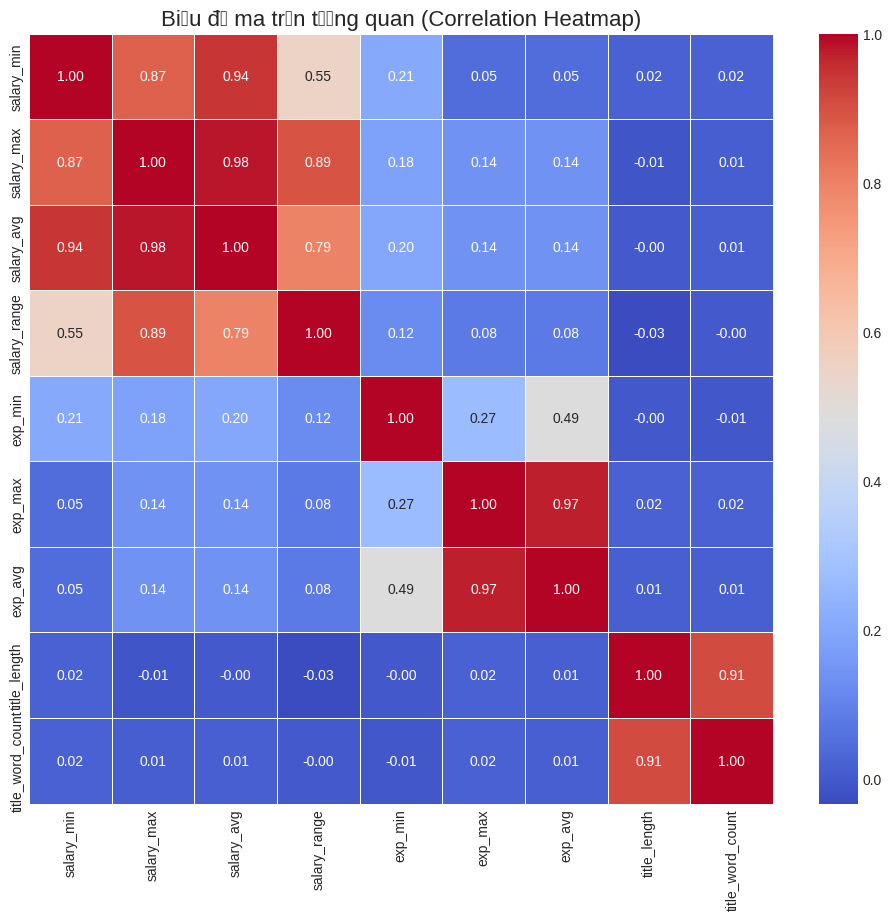

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns # Thường dùng seaborn vẽ ma trận tương quan cho đẹp

# 1. TẠO CÁC CỘT DỮ LIỆU ĐANG BỊ THIẾU

# Khoảng lương (Chênh lệch giữa lương max và min)
df['salary_range'] = df['salary_max'] - df['salary_min']

# Kinh nghiệm trung bình
df['exp_avg'] = (df['exp_min'] + df['exp_max']) / 2

# Độ dài tiêu đề công việc (số lượng ký tự)
df['title_length'] = df['title'].astype(str).str.len()

# Số từ trong tiêu đề công việc
df['title_word_count'] = df['title'].astype(str).str.split().str.len()

# (Đảm bảo rằng cột 'salary_avg' cũng đã được tạo từ các bước trước đó)
if 'salary_avg' not in df.columns:
    df['salary_avg'] = (df['salary_min'] + df['salary_max']) / 2

# 2. CHẠY LẠI ĐOẠN CODE TÍNH TƯƠNG QUAN
correlation_cols = [
    'salary_min', 'salary_max', 'salary_avg', 'salary_range',
    'exp_min', 'exp_max', 'exp_avg', 'title_length', 'title_word_count'
]

# Tính ma trận tương quan
corr_matrix = df[correlation_cols].corr()

# Vẽ biểu đồ Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Biểu đồ ma trận tương quan (Correlation Heatmap)", fontsize=16)
plt.show()

In [19]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'DejaVu Sans'   # hỗ trợ Unicode tốt
plt.rcParams['axes.unicode_minus'] = False    # tránh lỗi dấu âm

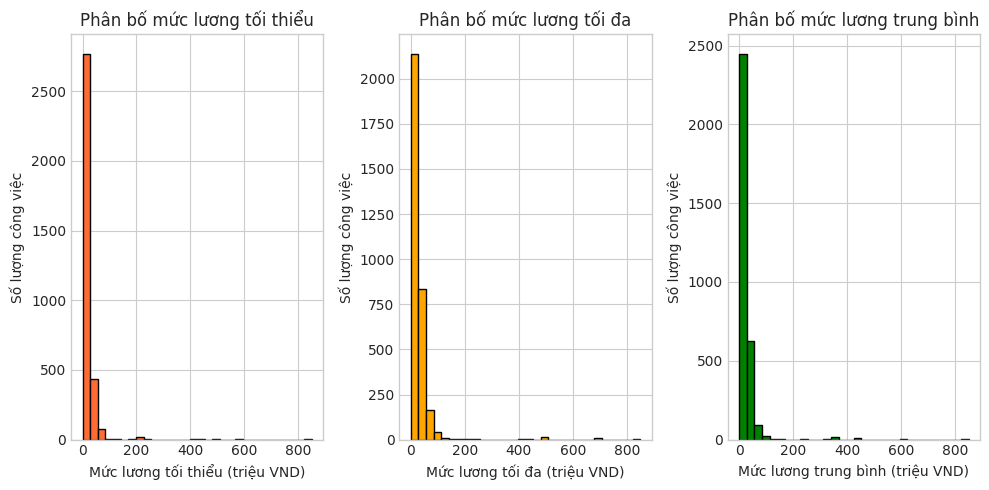

In [20]:
# Phân bố mức lương
fig, axes = plt.subplots(1, 3, figsize=(10, 5))

# Salary min
axes[0].hist(df['salary_min'] / 1_000_000, bins=30, edgecolor='black')
axes[0].set_xlabel('Mức lương tối thiểu (triệu VND)')
axes[0].set_ylabel('Số lượng công việc')
axes[0].set_title('Phân bố mức lương tối thiểu')

# Salary max
axes[1].hist(df['salary_max'] / 1_000_000, bins=30, edgecolor='black', color='orange')
axes[1].set_xlabel('Mức lương tối đa (triệu VND)')
axes[1].set_ylabel('Số lượng công việc')
axes[1].set_title('Phân bố mức lương tối đa')

# Salary avg
axes[2].hist(df['salary_avg'] / 1_000_000, bins=30, edgecolor='black', color='green')
axes[2].set_xlabel('Mức lương trung bình (triệu VND)')
axes[2].set_ylabel('Số lượng công việc')
axes[2].set_title('Phân bố mức lương trung bình')

plt.tight_layout()
plt.show()

Số lượng công việc theo nguồn:
source
topcv           5381
itviec          1913
vietnamworks    1635
Name: count, dtype: int64


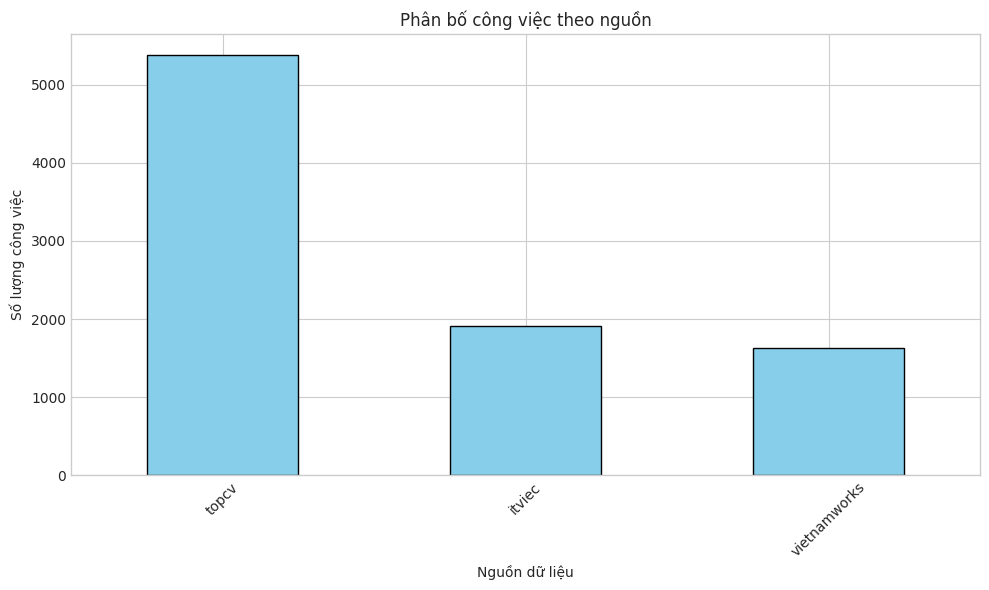

In [21]:
# Số lượng công việc theo source
source_counts = df['source'].value_counts()
print("Số lượng công việc theo nguồn:")
print(source_counts)

plt.figure(figsize=(10, 6))
source_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.xlabel('Nguồn dữ liệu')
plt.ylabel('Số lượng công việc')
plt.title('Phân bố công việc theo nguồn')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Mức lương trung bình theo nguồn (triệu VND):
              mean  median   std
source                          
itviec       50.44   39.38 80.06
topcv        19.68   16.00 12.71
vietnamworks 56.42   30.00 91.11


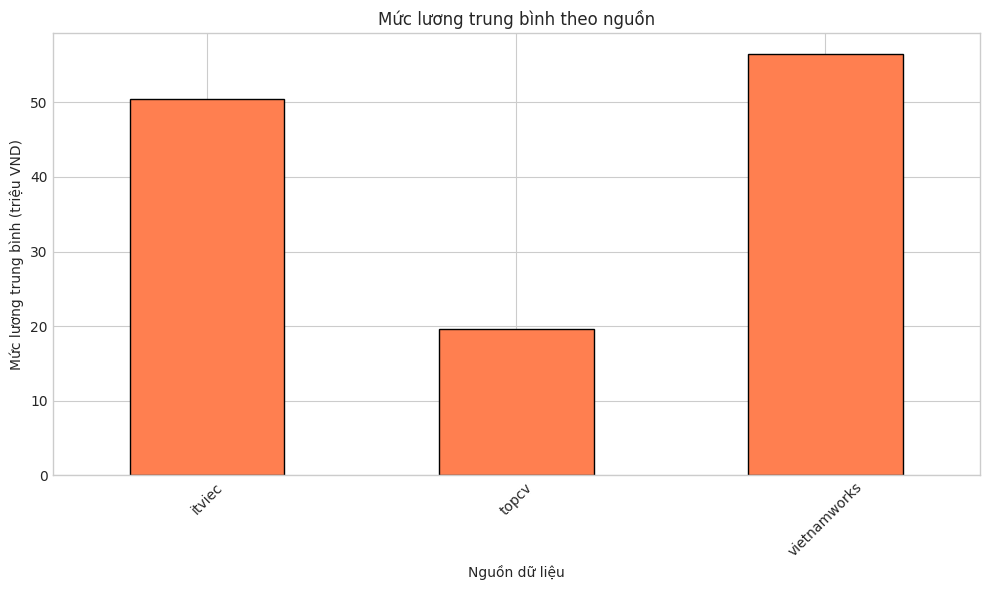

In [22]:
# So sánh mức lương theo source
salary_by_source = df.groupby('source')['salary_avg'].agg(['mean', 'median', 'std'])
salary_by_source = salary_by_source / 1_000_000  # Chuyển sang triệu
print("\nMức lương trung bình theo nguồn (triệu VND):")
print(salary_by_source.round(2))

plt.figure(figsize=(10, 6))
salary_by_source['mean'].plot(kind='bar', color='coral', edgecolor='black')
plt.xlabel('Nguồn dữ liệu')
plt.ylabel('Mức lương trung bình (triệu VND)')
plt.title('Mức lương trung bình theo nguồn')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Số lượng công việc theo cấp độ:
level_name
Manager      423
Senior       363
Director     104
Intern        70
Junior        30
Fresher       19
Mid-level     17
Name: count, dtype: int64


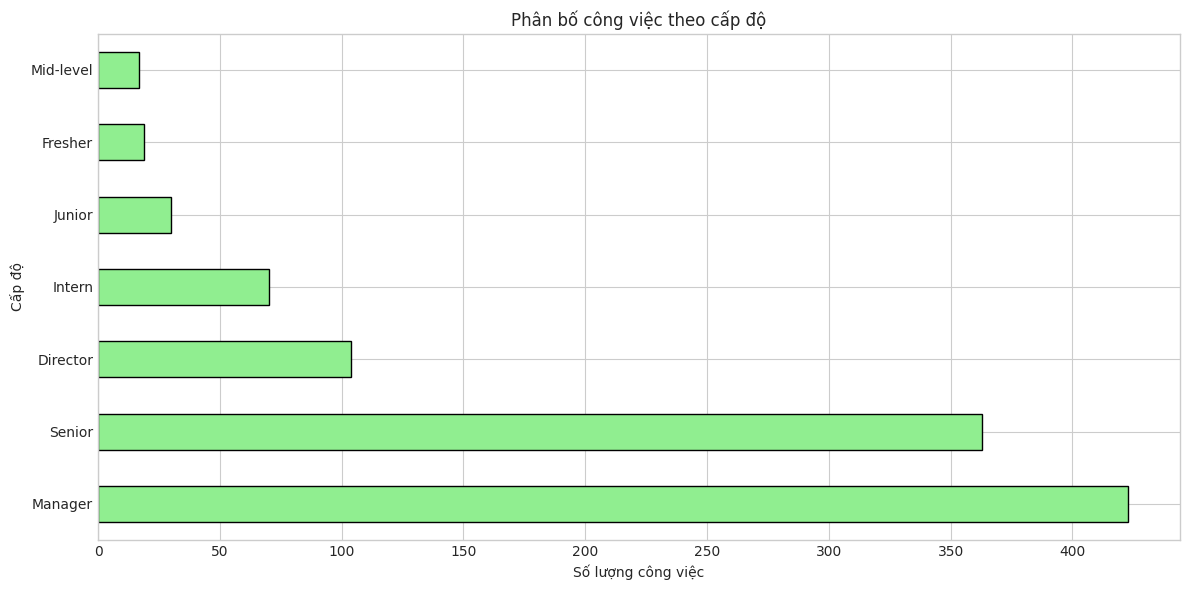

In [23]:
# Phân bố theo level
level_counts = df['level_name'].value_counts()
print("Số lượng công việc theo cấp độ:")
print(level_counts)

plt.figure(figsize=(12, 6))
level_counts.plot(kind='barh', color='lightgreen', edgecolor='black')
plt.xlabel('Số lượng công việc')
plt.ylabel('Cấp độ')
plt.title('Phân bố công việc theo cấp độ')
plt.tight_layout()
plt.show()


Mức lương theo cấp độ (triệu VND):
            mean  median  count
level_name                     
Manager    36.16   22.50    134
Director   34.18   25.00     32
Senior     30.02   26.25     75


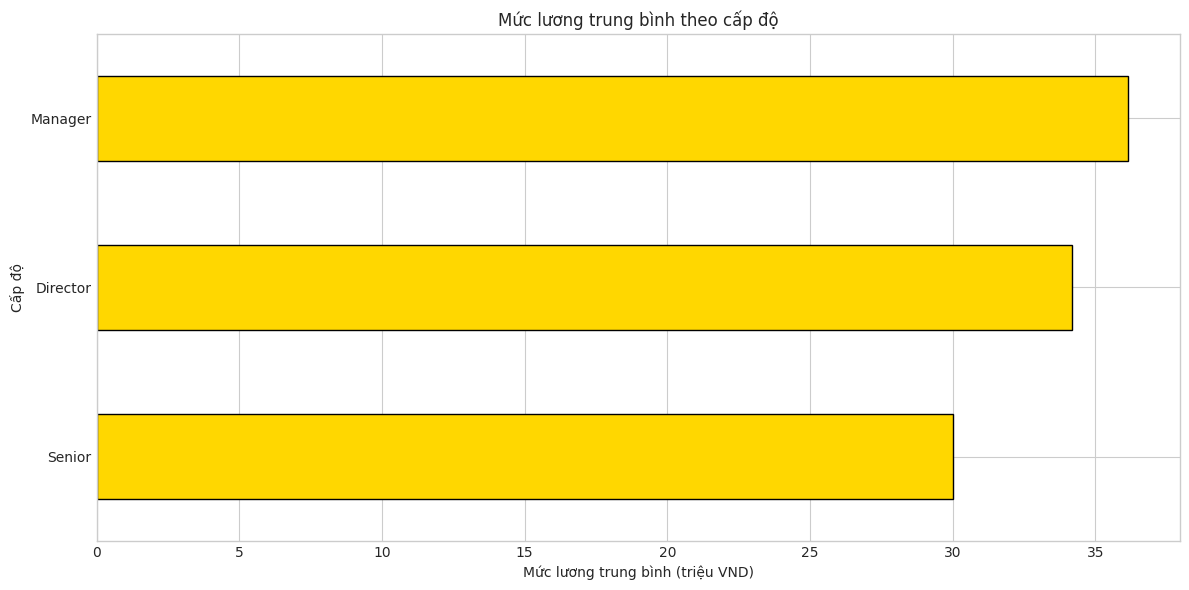

In [24]:
# Mức lương theo level (chỉ các level có đủ dữ liệu)
level_salary = df[df['level_name'] != 'Unknown'].groupby('level_name')['salary_avg'].agg(['mean', 'median', 'count'])
level_salary = level_salary[level_salary['count'] >= 10]  # Chỉ lấy level có ít nhất 10 jobs
level_salary['mean'] = level_salary['mean'] / 1_000_000
level_salary['median'] = level_salary['median'] / 1_000_000

print("\nMức lương theo cấp độ (triệu VND):")
print(level_salary.sort_values('mean', ascending=False).round(2))

plt.figure(figsize=(12, 6))
level_salary.sort_values('mean')['mean'].plot(kind='barh', color='gold', edgecolor='black')
plt.xlabel('Mức lương trung bình (triệu VND)')
plt.ylabel('Cấp độ')
plt.title('Mức lương trung bình theo cấp độ')
plt.tight_layout()
plt.show()

Top 10 thành phố có nhiều công việc:
city
Hà Nội       4768
TP.HCM       3551
Đà Nẵng       162
Hải Phòng      69
Bắc Ninh       58
Hưng Yên       39
Thanh Hóa      28
Nghệ An        27
Đồng Nai       27
Khánh Hòa      20
Name: count, dtype: int64


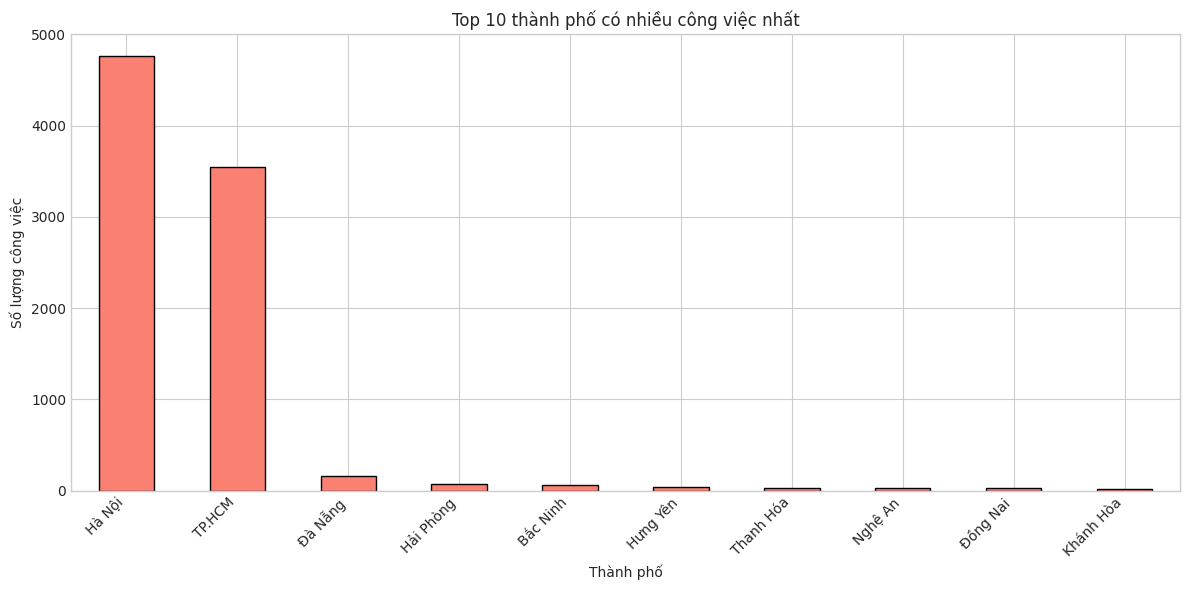

In [25]:
# Top 10 thành phố có nhiều công việc nhất
top_cities = df['city'].value_counts().head(10)
print("Top 10 thành phố có nhiều công việc:")
print(top_cities)

plt.figure(figsize=(12, 6))
top_cities.plot(kind='bar', color='salmon', edgecolor='black')
plt.xlabel('Thành phố')
plt.ylabel('Số lượng công việc')
plt.title('Top 10 thành phố có nhiều công việc nhất')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


So sánh mức lương Hà Nội vs TP.HCM (triệu VND):
        mean  median   std  count
city                             
Hà Nội 26.03   18.75 42.10   2144
TP.HCM 25.92   16.00 39.08    869


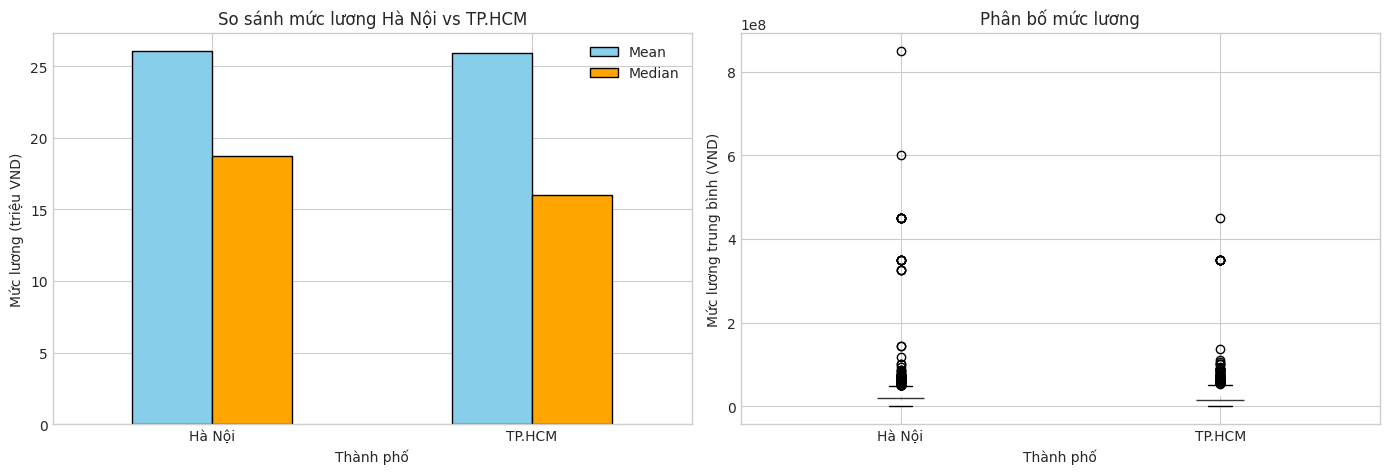

In [26]:
# So sánh mức lương giữa Hà Nội và TP.HCM
major_cities = df[df['city'].isin(['Hà Nội', 'TP.HCM'])]
city_salary_comparison = major_cities.groupby('city')['salary_avg'].agg(['mean', 'median', 'std', 'count'])
city_salary_comparison[['mean', 'median', 'std']] = city_salary_comparison[['mean', 'median', 'std']] / 1_000_000

print("\nSo sánh mức lương Hà Nội vs TP.HCM (triệu VND):")
print(city_salary_comparison.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ cột
city_salary_comparison[['mean', 'median']].plot(kind='bar', ax=axes[0], color=['skyblue', 'orange'], edgecolor='black')
axes[0].set_xlabel('Thành phố')
axes[0].set_ylabel('Mức lương (triệu VND)')
axes[0].set_title('So sánh mức lương Hà Nội vs TP.HCM')
axes[0].legend(['Mean', 'Median'])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Box plot
major_cities.boxplot(column='salary_avg', by='city', ax=axes[1])
axes[1].set_xlabel('Thành phố')
axes[1].set_ylabel('Mức lương trung bình (VND)')
axes[1].set_title('Phân bố mức lương')
plt.suptitle('')

plt.tight_layout()
plt.show()

Phân bố theo nhóm lương:
salary_category
Dưới 15 Triệu    1331
15-30 Triệu      1241
Trên 30 Triệu     645
Name: count, dtype: int64


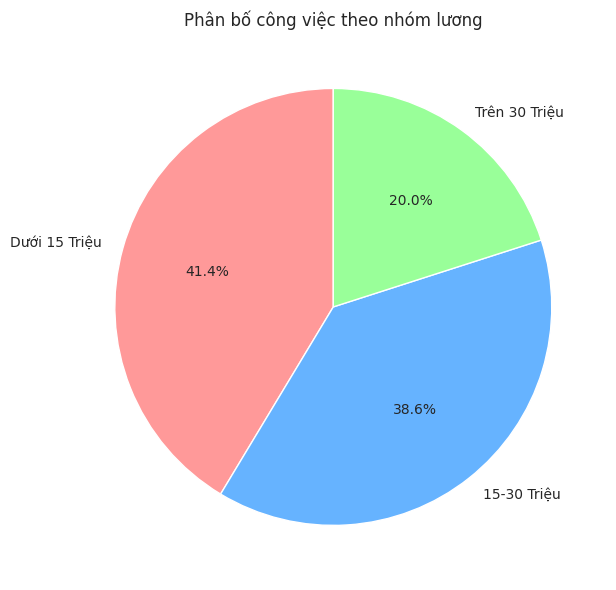

In [27]:
# Phân bố theo nhóm lương
salary_category_counts = df['salary_category'].value_counts().sort_index()
print("Phân bố theo nhóm lương:")
print(salary_category_counts)

plt.figure(figsize=(10, 6))
salary_category_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'])
plt.ylabel('')
plt.title('Phân bố công việc theo nhóm lương')
plt.tight_layout()
plt.show()


Phân bố theo nhóm kinh nghiệm:
exp_category
Dưới 1 năm    6966
1 - 3 năm     1150
3 - 5 năm      615
Trên 5 năm     198
Name: count, dtype: int64


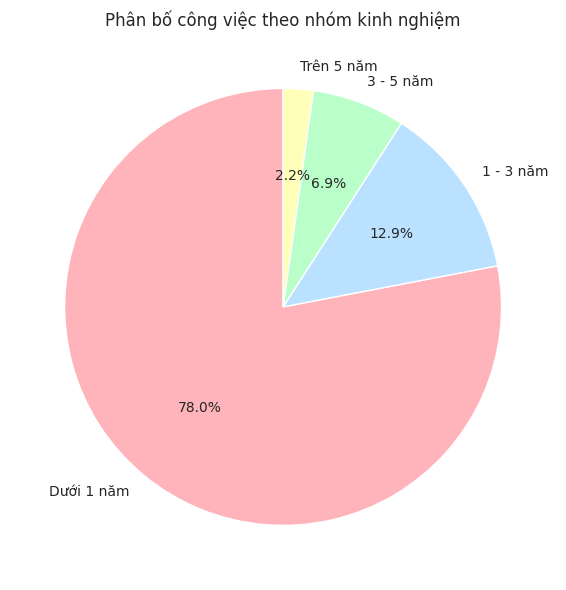

In [28]:
# Phân bố theo nhóm kinh nghiệm
exp_category_counts = df['exp_category'].value_counts().sort_index()
print("\nPhân bố theo nhóm kinh nghiệm:")
print(exp_category_counts)

plt.figure(figsize=(10, 6))
exp_category_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['#ffb3ba','#bae1ff','#baffc9','#ffffba'])
plt.ylabel('')
plt.title('Phân bố công việc theo nhóm kinh nghiệm')
plt.tight_layout()
plt.show()

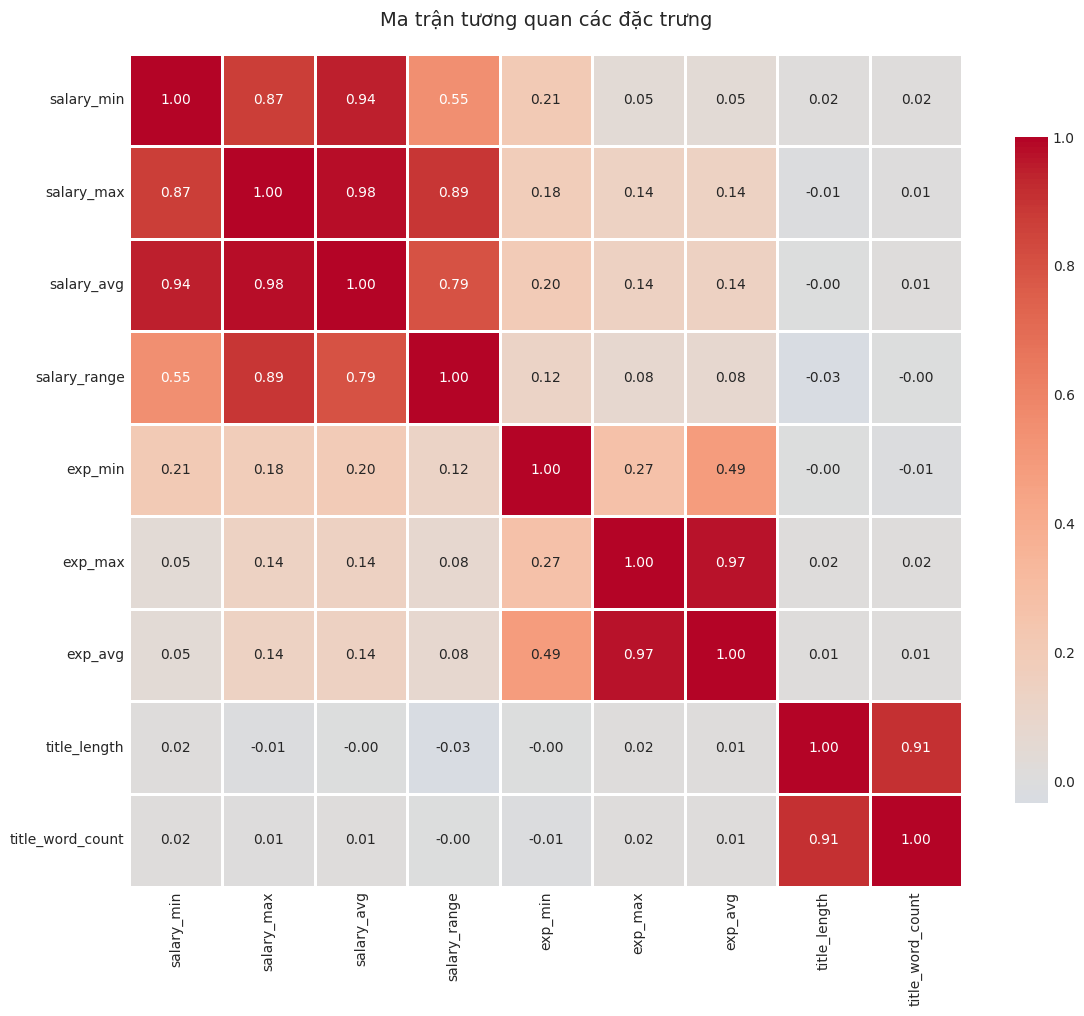

In [29]:
# Ma trận tương quan
correlation_cols = ['salary_min', 'salary_max', 'salary_avg', 'salary_range',
                    'exp_min', 'exp_max', 'exp_avg', 'title_length', 'title_word_count']

corr_matrix = df[correlation_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, fmt='.2f')
plt.title('Ma trận tương quan các đặc trưng', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

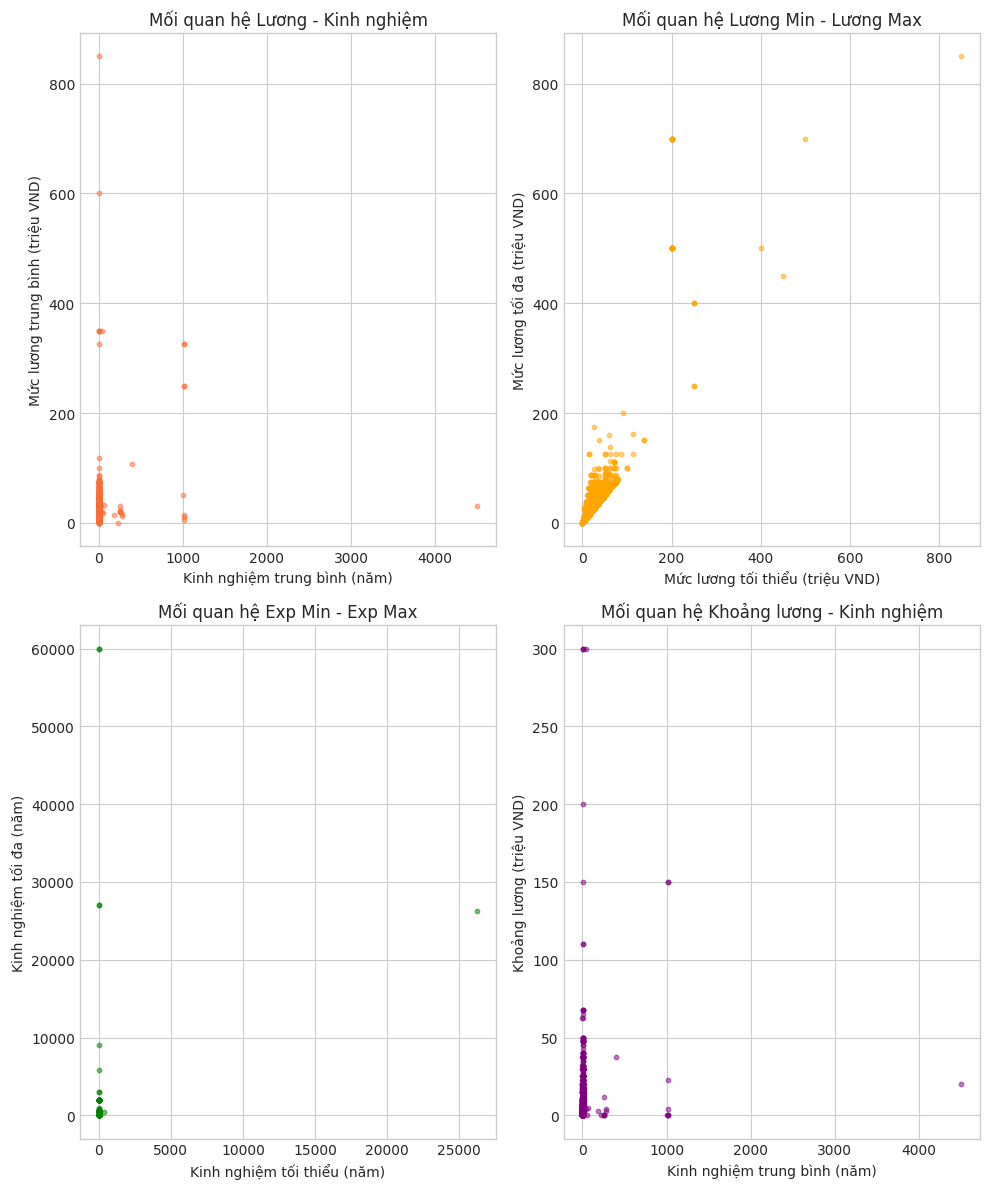

In [30]:
# Scatter plots quan trọng
fig, axes = plt.subplots(2, 2, figsize=(10, 12))

# Salary vs Experience
axes[0, 0].scatter(df['exp_avg'], df['salary_avg']/1_000_000, alpha=0.5, s=10)
axes[0, 0].set_xlabel('Kinh nghiệm trung bình (năm)')
axes[0, 0].set_ylabel('Mức lương trung bình (triệu VND)')
axes[0, 0].set_title('Mối quan hệ Lương - Kinh nghiệm')

# Salary min vs Salary max
axes[0, 1].scatter(df['salary_min']/1_000_000, df['salary_max']/1_000_000, alpha=0.5, s=10, color='orange')
axes[0, 1].set_xlabel('Mức lương tối thiểu (triệu VND)')
axes[0, 1].set_ylabel('Mức lương tối đa (triệu VND)')
axes[0, 1].set_title('Mối quan hệ Lương Min - Lương Max')

# Exp min vs Exp max
axes[1, 0].scatter(df['exp_min'], df['exp_max'], alpha=0.5, s=10, color='green')
axes[1, 0].set_xlabel('Kinh nghiệm tối thiểu (năm)')
axes[1, 0].set_ylabel('Kinh nghiệm tối đa (năm)')
axes[1, 0].set_title('Mối quan hệ Exp Min - Exp Max')

# Salary range vs Experience
axes[1, 1].scatter(df['exp_avg'], df['salary_range']/1_000_000, alpha=0.5, s=10, color='purple')
axes[1, 1].set_xlabel('Kinh nghiệm trung bình (năm)')
axes[1, 1].set_ylabel('Khoảng lương (triệu VND)')
axes[1, 1].set_title('Mối quan hệ Khoảng lương - Kinh nghiệm')

plt.tight_layout()
plt.show()

In [31]:
# Tạo báo cáo tổng hợp
summary = f"""
{'='*80}
BÁO CÁO PHÂN TÍCH DỮ LIỆU TUYỂN DỤNG
{'='*80}

1. THỐNG KÊ TỔNG QUÁT
{'-'*80}
   - Tổng số công việc: {len(df):,}
   - Số cột dữ liệu: {len(df.columns)}
   - Số nguồn dữ liệu: {df['source'].nunique()}
   - Số thành phố: {df['city'].nunique()}
   - Số cấp độ: {df['level_name'].nunique()}

2. THỐNG KÊ MỨC LƯƠNG (triệu VND)
{'-'*80}
   - Lương trung bình: {df['salary_avg'].mean()/1_000_000:.2f}
   - Lương median: {df['salary_avg'].median()/1_000_000:.2f}
   - Lương min: {df['salary_min'].min()/1_000_000:.2f}
   - Lương max: {df['salary_max'].max()/1_000_000:.2f}
   - Độ lệch chuẩn: {df['salary_avg'].std()/1_000_000:.2f}

3. THỐNG KÊ KINH NGHIỆM (năm)
{'-'*80}
   - Kinh nghiệm TB: {df['exp_avg'].mean():.2f}
   - Kinh nghiệm median: {df['exp_avg'].median():.2f}
   - Kinh nghiệm min: {df['exp_min'].min():.0f}
   - Kinh nghiệm max: {df['exp_max'].max():.0f}

4. TOP 5 THÀNH PHỐ CÓ NHIỀU CÔNG VIỆC NHẤT
{'-'*80}
"""

for i, (city, count) in enumerate(df['city'].value_counts().head(5).items(), 1):
    summary += f"   {i}. {city}: {count:,} công việc\n"

summary += f"""
5. TOP 5 CẤP ĐỘ PHỔ BIẾN
{'-'*80}
"""

for i, (level, count) in enumerate(df['level_name'].value_counts().head(5).items(), 1):
    summary += f"   {i}. {level}: {count:,} công việc\n"

summary += f"""
{'='*80}
KẾT THÚC BÁO CÁO
{'='*80}
"""

print(summary)




BÁO CÁO PHÂN TÍCH DỮ LIỆU TUYỂN DỤNG

1. THỐNG KÊ TỔNG QUÁT
--------------------------------------------------------------------------------
   - Tổng số công việc: 8,929
   - Số cột dữ liệu: 28
   - Số nguồn dữ liệu: 3
   - Số thành phố: 41
   - Số cấp độ: 7

2. THỐNG KÊ MỨC LƯƠNG (triệu VND)
--------------------------------------------------------------------------------
   - Lương trung bình: 25.67
   - Lương median: 17.50
   - Lương min: 0.00
   - Lương max: 850.00
   - Độ lệch chuẩn: 40.54

3. THỐNG KÊ KINH NGHIỆM (năm)
--------------------------------------------------------------------------------
   - Kinh nghiệm TB: 22.37
   - Kinh nghiệm median: 1.00
   - Kinh nghiệm min: 0
   - Kinh nghiệm max: 60000

4. TOP 5 THÀNH PHỐ CÓ NHIỀU CÔNG VIỆC NHẤT
--------------------------------------------------------------------------------
   1. Hà Nội: 4,768 công việc
   2. TP.HCM: 3,551 công việc
   3. Đà Nẵng: 162 công việc
   4. Hải Phòng: 69 công việc
   5. Bắc Ninh: 58 công việc

5. T

In [32]:
import pandas as pd

# 0. Đọc dữ liệu và khởi tạo dataframe xử lý
df = pd.read_csv("jobs_light.csv")
df_processed = df.copy() # Khởi tạo df_processed từ df để tránh lỗi NameError

# Xử lý missing values
df_processed['level_name'] = df_processed['level_name'].fillna('Unknown')
df_processed['role_name'] = df_processed['role_name'].astype(str).fillna('Unknown')
df_processed['city'] = df_processed['city'].fillna('Unknown')

df_processed['salary_avg'] = df_processed['salary_avg'].fillna(df_processed['salary_avg'].median())
df_processed['exp_max'] = df_processed['exp_max'].fillna(df_processed['exp_max'].median())
df_processed['exp_min'] = df_processed['exp_min'].fillna(0)

# 1. Salary range
df_processed['salary_range'] = df_processed['salary_max'] - df_processed['salary_min']
df_processed['salary_range'] = df_processed['salary_range'].fillna(0)

# 2. Experience range
df_processed['exp_range'] = df_processed['exp_max'] - df_processed['exp_min']

# 3. Title length
df_processed['title_length'] = df_processed['title'].astype(str).str.len()

# 4. Word count
df_processed['title_word_count'] = df_processed['title'].astype(str).str.split().str.len()

# 5. English requirement
df_processed['requires_english'] = df_processed['title'].str.contains('English|english', case=False, na=False).astype(int)

# 6. Japanese requirement
df_processed['requires_japanese'] = df_processed['title'].str.contains('Japanese|N1|N2|N3', case=False, na=False).astype(int)

# 7. Manager
df_processed['is_manager'] = df_processed['title'].str.contains('Manager|Lead|Head|Director', case=False, na=False).astype(int)

# 8. Senior (Thêm ký tự 'r' phía trước chuỗi regex để tránh lỗi escape character)
df_processed['is_senior'] = df_processed['title'].str.contains(r'Senior|Sr\.', case=False, na=False).astype(int)

# 9. Major city
major_cities = ['TP.HCM', 'Hà Nội', 'Đà Nẵng']
df_processed['is_major_city'] = df_processed['city'].isin(major_cities).astype(int)

# OUTPUT
print("\n✅ Đã tạo 9 đặc trưng mới")
new_features = [
    'salary_range', 'exp_range', 'title_length', 'title_word_count',
    'requires_english', 'requires_japanese', 'is_manager',
    'is_senior', 'is_major_city'
]

print("\n📊 Thống kê các feature:")
print(df_processed[new_features].describe())



✅ Đã tạo 9 đặc trưng mới

📊 Thống kê các feature:
       salary_range  exp_range  title_length  title_word_count  \
count       8929.00    8929.00       8929.00           8929.00   
mean     3867860.40      28.99         36.92              5.72   
std     19969355.00     996.73         20.10              3.94   
min            0.00    -807.00          6.00              1.00   
25%            0.00       0.00         23.00              3.00   
50%            0.00       1.00         34.00              5.00   
75%      3000000.00       2.00         46.00              7.00   
max    500000000.00   59997.00        177.00             40.00   

       requires_english  requires_japanese  is_manager  is_senior  \
count           8929.00            8929.00     8929.00    8929.00   
mean               0.02               0.01        0.09       0.12   
std                0.14               0.12        0.29       0.32   
min                0.00               0.00        0.00       0.00   
25%      

In [33]:
# Khởi tạo các biến để lưu trữ cấu hình
target = 'level_name'
label_encoders = {}
scaler = StandardScaler()

# 1. Lọc các level có đủ dữ liệu (>= 50 mẫu) để tránh mất cân bằng
level_counts = df_processed[target].value_counts()
valid_levels = level_counts[level_counts >= 50].index
df_ml = df_processed[df_processed[target].isin(valid_levels)].copy()

print(f"\nTarget: {target}")
print(f"Các nhãn: {df_ml[target].unique()}")
print(f"Phân phối target:\n{df_ml[target].value_counts()}")

# 2. Chọn features
feature_cols = [
    'salary_avg', 'exp_max', 'exp_min', 'salary_range', 'exp_range',
    'title_length', 'title_word_count', 'requires_english',
    'requires_japanese', 'is_manager', 'is_senior', 'is_major_city',
    'role_name', 'city', 'source'
]

# Lọc bỏ những cột không tồn tại trong df_ml để tránh lỗi
feature_cols = [col for col in feature_cols if col in df_ml.columns]

# 3. Encode categorical features (Chuyển chuỗi thành số)
print("\nEncoding categorical features...")
for col in ['role_name', 'city', 'source']:
    if col in feature_cols:
        le = LabelEncoder()
        df_ml[f'{col}_encoded'] = le.fit_transform(df_ml[col].astype(str))
        label_encoders[col] = le
        feature_cols.remove(col)
        feature_cols.append(f'{col}_encoded')

# 4. Encode target
le_target = LabelEncoder()
y = le_target.fit_transform(df_ml[target].astype(str))
label_encoders[target] = le_target

# 5. Tạo ma trận đặc trưng X và xử lý giá trị thiếu
X = df_ml[feature_cols].copy()
X = X.fillna(X.median())

print(f"\nKích thước dữ liệu: X={X.shape}, y={y.shape}")
print(f"Features được sử dụng ({len(feature_cols)}):")
for i, col in enumerate(feature_cols, 1):
    print(f"   {i}. {col}")

# 6. Chia tập Train/Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 7. Chuẩn hóa dữ liệu (Scaling)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nChia dữ liệu:")
print(f"   - Train: {X_train.shape[0]:,} mẫu ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"   - Test:  {X_test.shape[0]:,} mẫu ({X_test.shape[0]/len(X)*100:.1f}%)")


Target: level_name
Các nhãn: ['Unknown' 'Senior' 'Director' 'Manager' 'Intern']
Phân phối target:
level_name
Unknown     7903
Manager      423
Senior       363
Director     104
Intern        70
Name: count, dtype: int64

Encoding categorical features...

Kích thước dữ liệu: X=(8863, 15), y=(8863,)
Features được sử dụng (15):
   1. salary_avg
   2. exp_max
   3. exp_min
   4. salary_range
   5. exp_range
   6. title_length
   7. title_word_count
   8. requires_english
   9. requires_japanese
   10. is_manager
   11. is_senior
   12. is_major_city
   13. role_name_encoded
   14. city_encoded
   15. source_encoded

Chia dữ liệu:
   - Train: 7,090 mẫu (80.0%)
   - Test:  1,773 mẫu (20.0%)


In [34]:
target = 'level_name'
label_encoders = {}
scaler = StandardScaler()

# -------------------------------------------------------------------
# BƯỚC QUAN TRỌNG NHẤT: LOẠI BỎ NHÃN 'UNKNOWN' KHỎI DỮ LIỆU
# -------------------------------------------------------------------
df_clean = df_processed[df_processed[target] != 'Unknown'].copy()

# Tiếp tục lọc các level có >= 30 mẫu (hạ tiêu chuẩn xuống 30 vì đã bỏ Unknown)
level_counts = df_clean[target].value_counts()
valid_levels = level_counts[level_counts >= 30].index
df_ml = df_clean[df_clean[target].isin(valid_levels)].copy()

print(f"\n📊 Phân phối target SAU KHI DỌN DẸP:\n{df_ml[target].value_counts()}")

# Chọn features
feature_cols = [
    'salary_avg', 'exp_max', 'exp_min', 'salary_range', 'exp_range',
    'title_length', 'title_word_count', 'requires_english',
    'requires_japanese', 'is_manager', 'is_senior', 'is_major_city',
    'role_name', 'city', 'source'
]
feature_cols = [col for col in feature_cols if col in df_ml.columns]

# Encode Categorical
for col in ['role_name', 'city', 'source']:
    if col in feature_cols:
        le = LabelEncoder()
        df_ml[f'{col}_encoded'] = le.fit_transform(df_ml[col].astype(str))
        label_encoders[col] = le
        feature_cols.remove(col)
        feature_cols.append(f'{col}_encoded')

# Encode Target
le_target = LabelEncoder()
y = le_target.fit_transform(df_ml[target].astype(str))
label_encoders[target] = le_target

# Tạo X, y
X = df_ml[feature_cols].copy()
X = X.fillna(X.median())

# Chia Train/Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Chuẩn hóa
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {}
predictions = {}
target_names = label_encoders[target].classes_

# -------------------------------------------------------------------
# HUẤN LUYỆN LẠI MÔ HÌNH VỚI CLASS_WEIGHT='BALANCED'
# -------------------------------------------------------------------
print("\n🔄 Đang huấn luyện Logistic Regression...")

param_grid_lr = {
    'C': [0.1, 1, 10],
    'class_weight': ['balanced'], # Ép buộc mô hình chú ý đến các class ít dữ liệu
    'solver': ['lbfgs'],
    'max_iter': [2000]
}

lr = LogisticRegression(random_state=42)
grid_search_lr = GridSearchCV(lr, param_grid_lr, cv=5, scoring='f1_macro', n_jobs=-1)

grid_search_lr.fit(X_train_scaled, y_train)
best_lr = grid_search_lr.best_estimator_
models['Logistic Regression'] = best_lr

y_pred_lr = best_lr.predict(X_test_scaled)
y_pred_proba_lr = best_lr.predict_proba(X_test_scaled)
predictions['Logistic Regression'] = {'y_pred': y_pred_lr, 'y_pred_proba': y_pred_proba_lr}

# Đánh giá lại
print(f"\n📋 Classification Report MỚI:")
print(classification_report(y_test, y_pred_lr, target_names=target_names, zero_division=0))


📊 Phân phối target SAU KHI DỌN DẸP:
level_name
Manager     423
Senior      363
Director    104
Intern       70
Junior       30
Name: count, dtype: int64

🔄 Đang huấn luyện Logistic Regression...

📋 Classification Report MỚI:
              precision    recall  f1-score   support

    Director       0.20      0.19      0.20        21
      Intern       0.21      0.36      0.26        14
      Junior       0.17      0.83      0.29         6
     Manager       0.73      0.64      0.68        85
      Senior       0.96      0.68      0.80        72

    accuracy                           0.59       198
   macro avg       0.45      0.54      0.44       198
weighted avg       0.70      0.59      0.63       198



In [35]:
# Mở rộng không gian tìm kiếm
param_grid_rf = {
    'n_estimators': [100, 200],          # Số lượng cây quyết định trong rừng
    'max_depth': [10, 20, None],         # Độ sâu của cây (None là cho phép mọc sâu tối đa)
    'min_samples_split': [2, 5],         # Số lượng mẫu tối thiểu để chia nhánh
    'min_samples_leaf': [1, 2]           # Số lượng mẫu tối thiểu ở lá cuối cùng
}

# Thêm class_weight='balanced' để xử lý mất cân bằng dữ liệu
rf = RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1)

# Sử dụng cv=5 và scoring='f1_macro' tương tự Logistic Regression
grid_search_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='f1_macro', n_jobs=-1, verbose=1)

# Lưu ý: Random Forest hoạt động tốt với dữ liệu gốc KHÔNG CẦN scale
grid_search_rf.fit(X_train, y_train)

best_rf = grid_search_rf.best_estimator_
models['Random Forest'] = best_rf

print(f"\n✅ Best Parameters: {grid_search_rf.best_params_}")
print(f"✅ Best CV Score (F1-Macro): {grid_search_rf.best_score_:.4f}")

y_pred_rf = best_rf.predict(X_test)
y_pred_proba_rf = best_rf.predict_proba(X_test)
predictions['Random Forest'] = {'y_pred': y_pred_rf, 'y_pred_proba': y_pred_proba_rf}

# Đánh giá
print(f"\n📊 Đánh giá Random Forest:")
print(f"   ✓ Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"   ✓ Precision: {precision_score(y_test, y_pred_rf, average='weighted', zero_division=0):.4f}")
print(f"   ✓ Recall:    {recall_score(y_test, y_pred_rf, average='weighted', zero_division=0):.4f}")
print(f"   ✓ F1-Score:  {f1_score(y_test, y_pred_rf, average='weighted', zero_division=0):.4f}")

print(f"\n📋 Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=target_names, zero_division=0))

Fitting 5 folds for each of 24 candidates, totalling 120 fits

✅ Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
✅ Best CV Score (F1-Macro): 0.4983

📊 Đánh giá Random Forest:
   ✓ Accuracy:  0.6919
   ✓ Precision: 0.7074
   ✓ Recall:    0.6919
   ✓ F1-Score:  0.6839

📋 Classification Report:
              precision    recall  f1-score   support

    Director       0.20      0.10      0.13        21
      Intern       0.45      0.64      0.53        14
      Junior       0.30      0.50      0.38         6
     Manager       0.69      0.86      0.76        85
      Senior       0.96      0.69      0.81        72

    accuracy                           0.69       198
   macro avg       0.52      0.56      0.52       198
weighted avg       0.71      0.69      0.68       198



In [36]:
# Mở rộng không gian tìm kiếm
param_grid_lgbm = {
    'n_estimators': [100, 200],          # Số lượng cây
    'max_depth': [5, 10],                # Độ sâu tối đa của cây
    'learning_rate': [0.05, 0.1],        # Tốc độ học (nhỏ thì học kỹ hơn nhưng lâu hơn)
    'num_leaves': [31, 50]               # Số lượng lá tối đa trên một cây
}

# Thêm class_weight='balanced' để xử lý mất cân bằng dữ liệu
lgbm = lgb.LGBMClassifier(random_state=42, class_weight='balanced', verbose=-1)

# Sử dụng cv=5 và scoring='f1_macro' tương tự các mô hình trước
grid_search_lgbm = GridSearchCV(lgbm, param_grid_lgbm, cv=5, scoring='f1_macro', n_jobs=-1, verbose=1)

# Lưu ý: LightGBM KHÔNG CẦN dữ liệu đã scale
grid_search_lgbm.fit(X_train, y_train)

best_lgbm = grid_search_lgbm.best_estimator_
models['LightGBM'] = best_lgbm

print(f"\n✅ Best Parameters: {grid_search_lgbm.best_params_}")
print(f"✅ Best CV Score (F1-Macro): {grid_search_lgbm.best_score_:.4f}")

y_pred_lgbm = best_lgbm.predict(X_test)
y_pred_proba_lgbm = best_lgbm.predict_proba(X_test)
predictions['LightGBM'] = {'y_pred': y_pred_lgbm, 'y_pred_proba': y_pred_proba_lgbm}

# Đánh giá
print(f"\n📊 Đánh giá LightGBM:")
print(f"   ✓ Accuracy:  {accuracy_score(y_test, y_pred_lgbm):.4f}")
print(f"   ✓ Precision: {precision_score(y_test, y_pred_lgbm, average='weighted', zero_division=0):.4f}")
print(f"   ✓ Recall:    {recall_score(y_test, y_pred_lgbm, average='weighted', zero_division=0):.4f}")
print(f"   ✓ F1-Score:  {f1_score(y_test, y_pred_lgbm, average='weighted', zero_division=0):.4f}")

print(f"\n📋 Classification Report:")
print(classification_report(y_test, y_pred_lgbm, target_names=target_names, zero_division=0))

Fitting 5 folds for each of 16 candidates, totalling 80 fits

✅ Best Parameters: {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 100, 'num_leaves': 31}
✅ Best CV Score (F1-Macro): 0.4808

📊 Đánh giá LightGBM:
   ✓ Accuracy:  0.7020
   ✓ Precision: 0.6973
   ✓ Recall:    0.7020
   ✓ F1-Score:  0.6989

📋 Classification Report:
              precision    recall  f1-score   support

    Director       0.37      0.33      0.35        21
      Intern       0.58      0.50      0.54        14
      Junior       0.50      0.50      0.50         6
     Manager       0.74      0.79      0.76        85
      Senior       0.79      0.76      0.77        72

    accuracy                           0.70       198
   macro avg       0.59      0.58      0.58       198
weighted avg       0.70      0.70      0.70       198



In [37]:
results = []

# Duyệt qua từng mô hình đã được lưu trong dictionary 'models'
for model_name in models.keys():
    # Lấy nhãn dự đoán từ dictionary 'predictions' đã tạo ở bước 5, 6, 7
    y_pred = predictions[model_name]['y_pred']

    # Tính toán và lưu các chỉ số đánh giá
    results.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, average='weighted', zero_division=0)
    })

# Chuyển list kết quả thành DataFrame để hiển thị cho đẹp
results_df = pd.DataFrame(results)
results_df = results_df.round(4)

# Sắp xếp bảng kết quả giảm dần theo F1-Score để dễ so sánh (tuỳ chọn)
results_df = results_df.sort_values(by='F1-Score', ascending=False)

print("\nBảng so sánh hiệu suất các mô hình:")
print(results_df.to_string(index=False))


Bảng so sánh hiệu suất các mô hình:
              Model  Accuracy  Precision  Recall  F1-Score
           LightGBM      0.70       0.70    0.70      0.70
      Random Forest      0.69       0.71    0.69      0.68
Logistic Regression      0.59       0.70    0.59      0.63


<Figure size 1200x600 with 0 Axes>

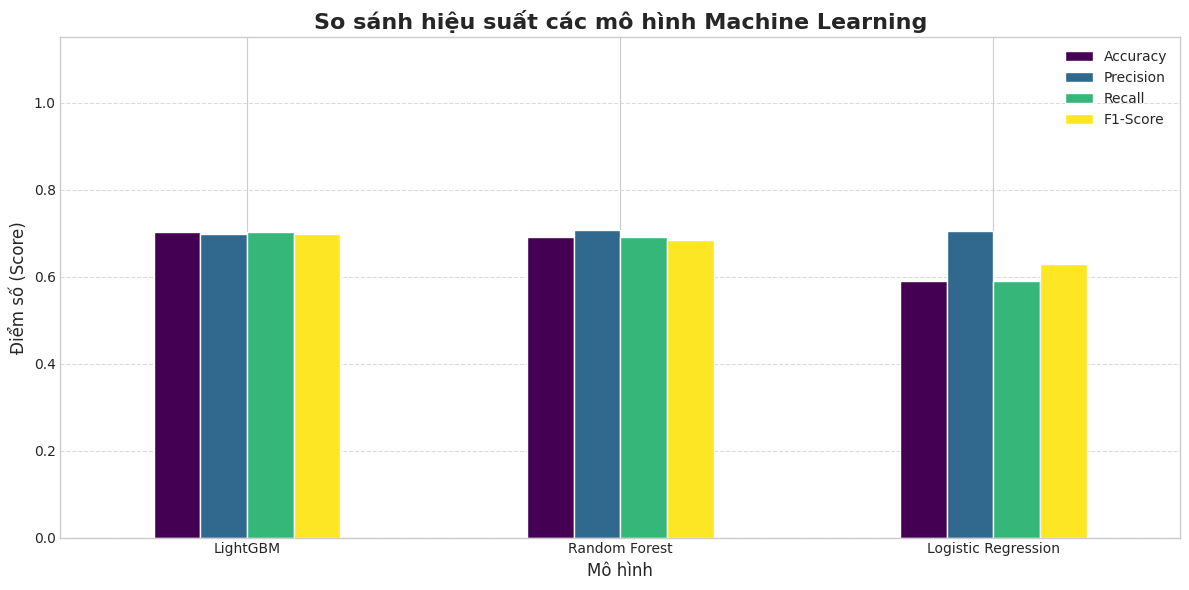

In [38]:
plt.figure(figsize=(12, 6))
ax = results_df.set_index('Model').plot(kind='bar', figsize=(12, 6), colormap='viridis', rot=0)

plt.title('So sánh hiệu suất các mô hình Machine Learning', fontsize=16, fontweight='bold')
plt.ylabel('Điểm số (Score)', fontsize=12)
plt.xlabel('Mô hình', fontsize=12)
plt.ylim(0, 1.15) # Mở rộng trục Y một chút để có chỗ hiển thị chú thích (legend)
plt.legend(loc='upper right', bbox_to_anchor=(1, 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

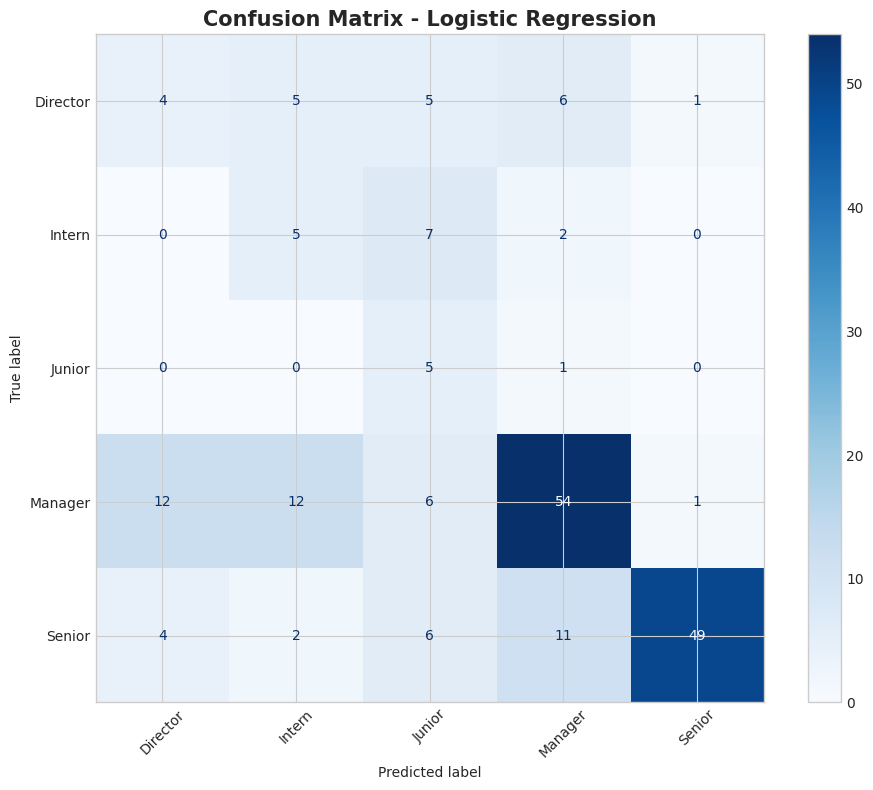

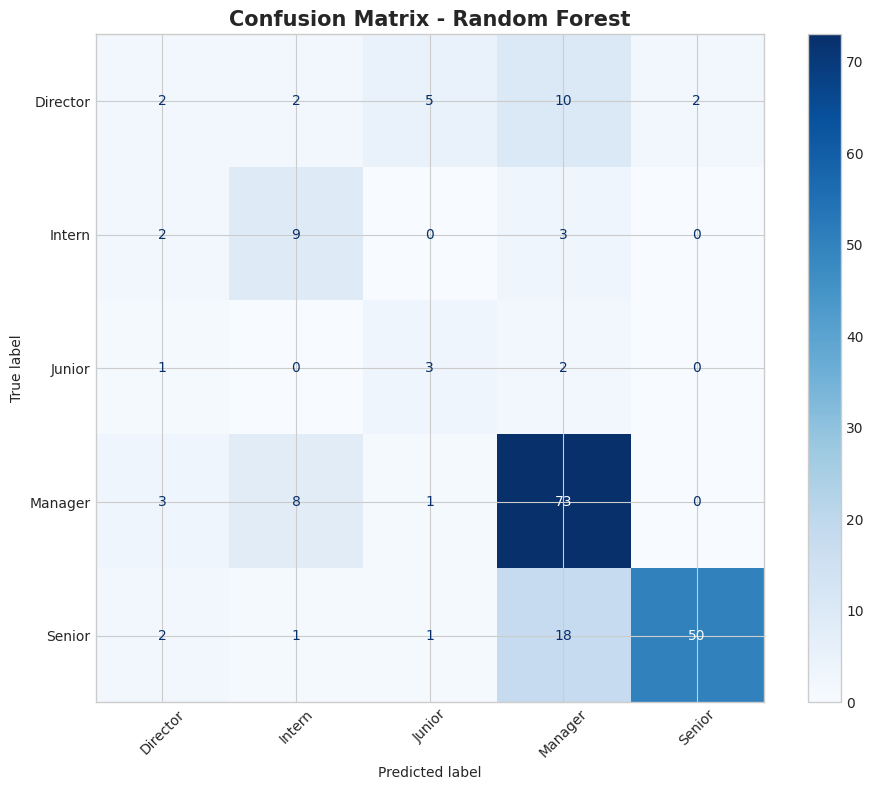

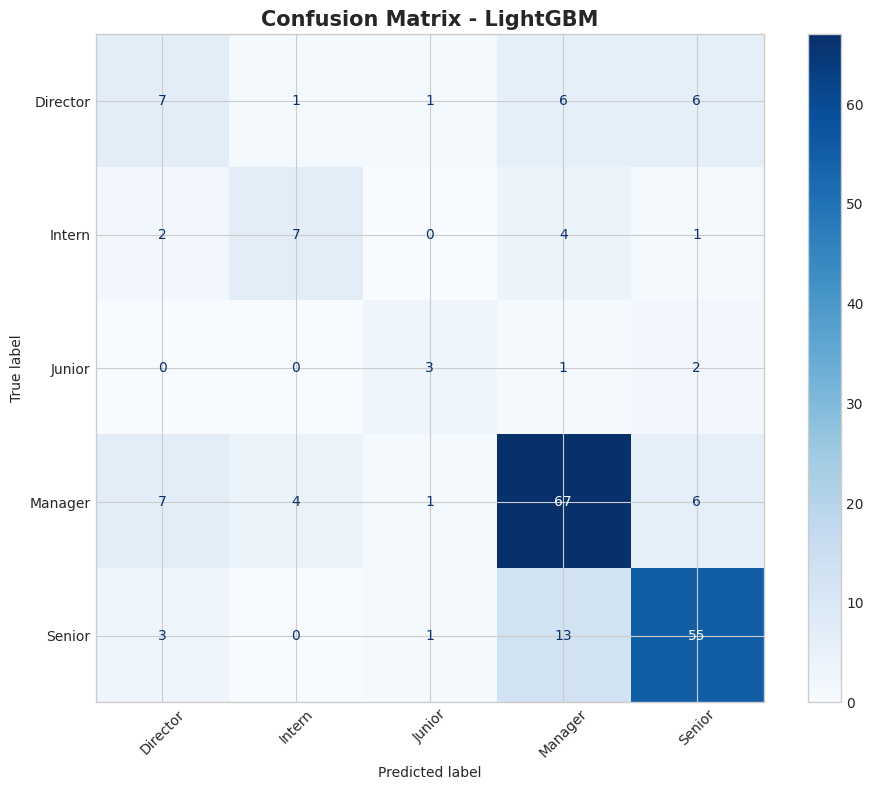

In [39]:
from sklearn.metrics import ConfusionMatrixDisplay
for model_name in models.keys():
    # Lấy dự đoán từ dictionary 'predictions'
    y_pred = predictions[model_name]['y_pred']

    # Tính toán Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    # Sử dụng ConfusionMatrixDisplay của Sklearn để vẽ cho đẹp
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)

    fig, ax = plt.subplots(figsize=(10, 8))
    # Sử dụng color map 'Blues' cho dễ nhìn
    disp.plot(cmap='Blues', ax=ax, xticks_rotation=45)

    plt.title(f'Confusion Matrix - {model_name}', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

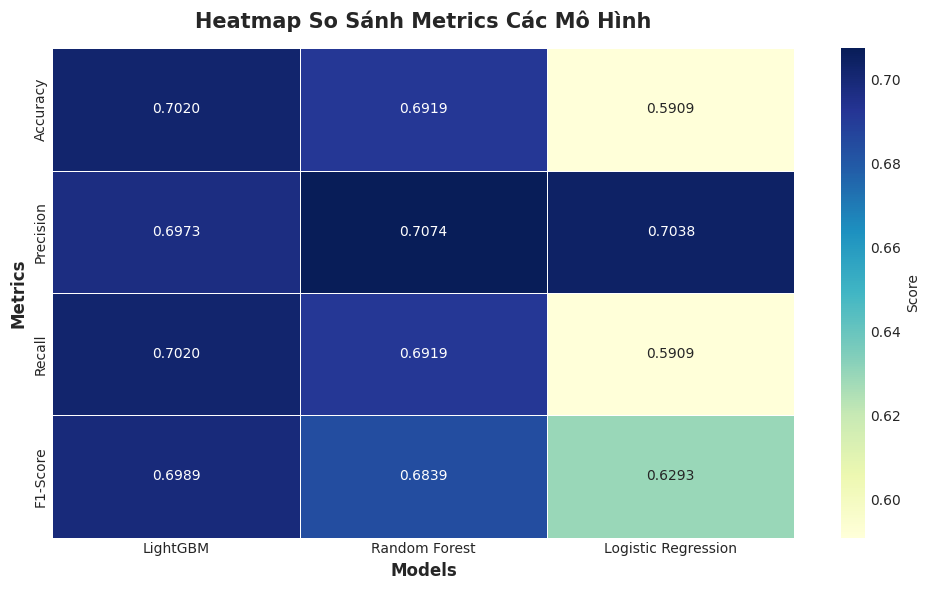

In [40]:
# 1. Xác định danh sách các cột metrics cần hiển thị
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

# 2. Chuẩn bị dữ liệu: Đặt cột Model làm index, chỉ lấy các cột metrics và chuyển vị (Transpose - .T)
data_for_heatmap = results_df.set_index('Model')[metrics].T

# 3. Khởi tạo một Figure độc lập thay vì dùng axes[1]
plt.figure(figsize=(10, 6))

# 4. Vẽ Heatmap
# Thêm linewidths=0.5 để tạo đường viền mỏng giữa các ô cho dễ nhìn hơn
sns.heatmap(data_for_heatmap, annot=True, fmt='.4f', cmap='YlGnBu',
            cbar_kws={'label': 'Score'}, linewidths=0.5)

# Căn chỉnh tiêu đề và trục
plt.title('Heatmap So Sánh Metrics Các Mô Hình', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Models', fontsize=12, fontweight='bold')
plt.ylabel('Metrics', fontsize=12, fontweight='bold')

plt.tight_layout()

In [41]:
from collections import Counter
import pandas as pd

print("\n" + "="*80)
print("12. KIỂM THỬ, HIỆU CHỈNH CẤP ĐỘ VÀ GỢI Ý CÔNG CỤ THEO ROLE")
print("="*80)

# 1. THÊM TRƯỜNG 'job_role' CHO NGƯỜI DÙNG
test_users = [
    {
        'profile_name': 'Sinh viên mới ra trường (Định hướng Backend)',
        'job_role': 'Backend Developer',
        'salary_expectation': 40000000,
        'experience_years': 0,
        'preferred_city': 'Hà Nội',
        'english_level': 1,
        'japanese_level': 0
    },
    {
        'profile_name': 'Mid-level Developer (Frontend)',
        'job_role': 'Frontend Developer',
        'salary_expectation': 30000000,
        'experience_years': 4,
        'preferred_city': 'TP.HCM',
        'english_level': 1,
        'japanese_level': 0
    },
    {
        'profile_name': 'Senior Data Engineer with Japanese',
        'job_role': 'Data Engineer',
        'salary_expectation': 55000000,
        'experience_years': 7,
        'preferred_city': 'Đà Nẵng',
        'english_level': 1,
        'japanese_level': 1
    }
]

# 2. TỪ ĐIỂN LỘ TRÌNH ĐƯỢC CHIA THEO VỊ TRÍ (ROLE) VÀ CẤP ĐỘ (LEVEL)
learning_paths = {
    'Backend': {
        'Intern': ["Công cụ: Git/GitHub, Postman cơ bản.", "Nền tảng: Hiểu HTTP/HTTPS, RESTful API cơ bản.", "Ngôn ngữ: Nắm vững cú pháp Core (Java, Python, C#...)."],
        'Fresher': ["Công cụ: SQL (MySQL/PostgreSQL), Docker cơ bản.", "Framework: Spring Boot, Django, hoặc .NET Core.", "Kỹ năng: Xây dựng CRUD API, đọc hiểu log lỗi."],
        'Junior': ["Công cụ: Redis (Caching), viết Unit Test (JUnit, PyTest).", "Database: Tối ưu query (Indexing), giải quyết N+1 query problem.", "Kỹ năng: Nắm vững SOLID principles, Clean Code."],
        'Mid-level': ["Công cụ: Message Brokers (Kafka, RabbitMQ), CI/CD (GitHub Actions/Jenkins).", "Kiến trúc: Bắt đầu làm quen với Microservices, Database Replication.", "Kỹ năng: Code Review, tự debug các luồng phức tạp."],
        'Senior': ["Công cụ: Kubernetes (K8s), Cloud Services (AWS/GCP), ELK Stack (Logging).", "Kiến trúc: System Design chịu tải cao (High Availability, Scalability), Bảo mật (OAuth2).", "Kỹ năng: Mentoring (hướng dẫn junior), định hình kiến trúc hệ thống."],
        'Manager': ["Công cụ: Jira, Trello, công cụ phân tích Performance.", "Kỹ năng: Quản lý rủi ro dự án, đánh giá KPI, Cân bằng giữa Technical Debt và tiến độ tính năng."]
    },
    'Frontend': {
        'Intern': ["Công cụ: Git/GitHub, VS Code.", "Nền tảng: HTML5, CSS3 (Flexbox/Grid), JavaScript DOM.", "Kỹ năng: Cắt giao diện tĩnh từ Figma cơ bản."],
        'Fresher': ["Công cụ: npm/yarn, Vite/Webpack cơ bản.", "Framework: Nắm vững ReactJS, VueJS hoặc Angular. Gọi API bằng Axios/Fetch.", "Kỹ năng: Quản lý State (Redux, Vuex, Context API)."],
        'Junior': ["Công cụ: TypeScript, TailwindCSS / SCSS, Cypress/Jest (Testing).", "Kỹ năng: Tối ưu UI/UX, Responsive Design chuẩn, xử lý Form phức tạp."],
        'Mid-level': ["Công cụ: Next.js/Nuxt.js (SSR/SSG), CI/CD cho Frontend.", "Kỹ năng: Tối ưu Web Performance (Lighthouse, Lazy load), Kiến trúc Component tái sử dụng."],
        'Senior': ["Công cụ: Micro-frontend architecture, Webpack nâng cao, WebGL/Canvas (nếu làm app phức tạp).", "Kỹ năng: Quản lý state toàn hệ thống lớn, Security (XSS, CSRF), chuẩn hóa UI System."],
        'Manager': ["Đồng nhất Tech-stack cho toàn team Front-end, phối hợp chặt với UI/UX Designer và Backend team."]
    },
    'Data': {
        'Intern': ["Công cụ: Excel nâng cao, SQL cơ bản.", "Nền tảng: Python (Pandas, Numpy), hiểu các loại join trong Database."],
        'Fresher': ["Công cụ: PowerBI/Tableau cơ bản, Python Web Scraping.", "Kỹ năng: Viết SQL complex queries, làm sạch dữ liệu (Data Cleaning) cơ bản."],
        'Junior': ["Công cụ: Airflow/Prefect (Orchestration), dbt, Cloud Storage (S3).", "Kỹ năng: Xây dựng ETL/ELT pipelines tự động, Tối ưu Data Warehouse."],
        'Mid-level': ["Công cụ: Apache Spark, Kafka, Snowflake/BigQuery.", "Kỹ năng: Xử lý Streaming Data, Data Modeling (Star/Snowflake schema), thiết kế Data Lake."],
        'Senior': ["Công cụ: ML Ops (MLflow), Kiến trúc Data Mesh/Data Fabric.", "Kỹ năng: Thiết kế hệ thống dữ liệu phân tán quy mô Petabytes, Quản trị Data Governance."],
        'Manager': ["Xây dựng chiến lược dữ liệu cho doanh nghiệp, bảo mật dữ liệu khách hàng (Compliance)."]
    },
    'General': { # Fallback cho các vị trí chung chung không xác định
        'Intern': ["Làm quen môi trường, công cụ quản lý code (Git).", "Hiểu logic lập trình cơ bản."],
        'Fresher': ["Thành thạo 1 ngôn ngữ, tự code được chức năng nhỏ.", "Biết dùng Database cơ bản."],
        'Junior': ["Thành thạo Framework, biết tự debug, viết code gọn gàng."],
        'Mid-level': ["Tham gia thiết kế hệ thống, sử dụng Cloud/DevOps cơ bản.", "Có khả năng Code Review."],
        'Senior': ["Thiết kế kiến trúc hệ thống lớn, giải quyết bài toán hiệu năng.", "Hướng dẫn (Mentoring)."],
        'Manager': ["Quản lý dự án, con người, giao tiếp liên phòng ban."]
    }
}

# Hàm hỗ trợ lấy role an toàn
def get_safe_role_encoded(le_dict):
    if 'role_name' not in le_dict:
        return 0
    classes = le_dict['role_name'].classes_
    for i, c in enumerate(classes):
        if any(kw in str(c).lower() for kw in ['developer', 'engineer', 'lập trình']):
            return i
    return len(classes) // 2

role_safe_encoded = get_safe_role_encoded(label_encoders)

for user in test_users:
    print("\n" + "="*80)
    print(f"👤 NGƯỜI DÙNG: {user['profile_name'].upper()}")
    print("=" * 80)

    # Phân loại Job Role để lấy đúng lộ trình
    user_role_str = str(user.get('job_role', 'General')).lower()
    if 'backend' in user_role_str: path_category = 'Backend'
    elif 'frontend' in user_role_str or 'front-end' in user_role_str: path_category = 'Frontend'
    elif 'data' in user_role_str: path_category = 'Data'
    else: path_category = 'General'

    for key, value in user.items():
        if key != 'profile_name':
            print(f"   - {key}: {value}")

    city_encoded_val = 0
    if 'city' in label_encoders:
        try:
            city_encoded_val = label_encoders['city'].transform([user.get('preferred_city')])[0]
        except:
            city_encoded_val = 0

    exp_years = user.get('experience_years', 0)

    sample_data = {
        'salary_avg': user.get('salary_expectation', 25000000),
        'exp_max': exp_years,
        'exp_min': max(0, exp_years - 2),
        'salary_range': 5000000 if exp_years > 0 else 0,
        'exp_range': 2 if exp_years > 0 else 0,
        'title_length': 30 + (exp_years * 5),
        'title_word_count': 5 + (exp_years // 2),
        'requires_english': user.get('english_level', 0),
        'requires_japanese': user.get('japanese_level', 0),
        'is_manager': 1 if exp_years >= 6 else 0,
        'is_senior': 1 if exp_years >= 4 else 0,
        'is_major_city': 1 if user.get('preferred_city') in ['TP.HCM', 'Hà Nội', 'Đà Nẵng'] else 0,
        'role_name_encoded': role_safe_encoded,
        'city_encoded': city_encoded_val,
        'source_encoded': 0
    }

    X_sample = pd.DataFrame([sample_data])
    for col in feature_cols:
        if col not in X_sample.columns:
            X_sample[col] = 0
    X_sample = X_sample[feature_cols]

    # Dự đoán
    results_pred = {}
    for model_name, model in models.items():
        if model_name == 'Logistic Regression':
            X_input = scaler.transform(X_sample)
        else:
            X_input = X_sample

        pred = model.predict(X_input)[0]
        results_pred[model_name] = label_encoders[target].inverse_transform([int(pred)])[0]

    # Bầu chọn
    level_votes = list(results_pred.values())
    most_common = Counter(level_votes).most_common(1)[0]
    ml_recommended_level = most_common[0]

    # HIỆU CHỈNH CẤP ĐỘ
    recommended_level = ml_recommended_level
    print(f"\n   🤖 Cấp độ AI dự đoán gốc: {ml_recommended_level}")

    if recommended_level == 'Unknown':
        if exp_years == 0: recommended_level = 'Intern'
        elif exp_years <= 1: recommended_level = 'Fresher'
        elif exp_years <= 2: recommended_level = 'Junior'
        elif exp_years <= 4: recommended_level = 'Mid-level'
        else: recommended_level = 'Senior'
        print(f"   ⚠️ HỆ THỐNG CAN THIỆP: Lọc bỏ nhãn rác 'Unknown', ép về '{recommended_level}'.")
    else:
        if exp_years == 0 and recommended_level not in ['Intern', 'Fresher']:
            recommended_level = 'Intern'
            print(f"   ⚠️ HỆ THỐNG CAN THIỆP: Đã hạ xuống '{recommended_level}' vì chưa có kinh nghiệm thực tế.")
        elif exp_years > 0 and exp_years < 2 and recommended_level in ['Senior', 'Manager']:
            recommended_level = 'Junior'
            print(f"   ⚠️ HỆ THỐNG CAN THIỆP: Đã hạ xuống '{recommended_level}' vì kinh nghiệm chưa đủ.")
        elif exp_years >= 5 and recommended_level in ['Intern', 'Fresher', 'Junior']:
            recommended_level = 'Senior'
            print(f"   ⚠️ HỆ THỐNG CAN THIỆP: Đã nâng lên '{recommended_level}' dựa trên số năm kinh nghiệm.")

    print(f"\n   ✨ CẤP ĐỘ KHUYẾN NGHỊ CUỐI CÙNG: {recommended_level}")

    # ----------------------------------------------------------------------
    # GỢI Ý LỘ TRÌNH VÀ CÔNG CỤ HỌC TẬP (THEO TỪNG ROLE)
    # ----------------------------------------------------------------------
    print(f"\n   📍 LỘ TRÌNH & CÔNG CỤ HỌC TẬP (Role: {path_category.upper()}):")
    levels_order = ['Intern', 'Fresher', 'Junior', 'Mid-level', 'Senior', 'Manager']

    try:
        current_idx = levels_order.index(recommended_level)
    except ValueError:
        current_idx = 0

    for i in range(current_idx, len(levels_order)):
        level = levels_order[i]

        if i == current_idx:
            print(f"      ➤ {level.upper()} (BẠN ĐANG Ở ĐÂY)")
            print("         [Mục tiêu]: Hoàn thiện các công cụ và kỹ năng hiện tại.")
            # In công cụ cần nắm vững cho level hiện tại
            current_tips = learning_paths[path_category].get(level, ["Tiếp tục trau dồi chuyên môn."])
            for tip in current_tips:
                print(f"         • {tip}")
        else:
            print(f"\n      ↑ ĐỂ THĂNG TIẾN LÊN: {level.upper()}")
            # Lấy lời khuyên học tập để chuẩn bị cho level tiếp theo
            next_tips = learning_paths[path_category].get(level, ["Học các kỹ năng nâng cao của mảng này."])
            for tip in next_tips:
                print(f"         • Cần học: {tip}")

    # Lời khuyên cá nhân hóa
    print("\n   💡 LỜI KHUYÊN CÁ NHÂN HÓA:")
    if user.get('english_level', 0) == 0:
        print("      🚩 Tiếng Anh: Trở ngại lớn! Việc không có Tiếng Anh làm giảm 40% cơ hội việc làm và mức lương.")
    else:
        print("      ⭐ Tiếng Anh: Tốt! Giữ vững lợi thế này để tiếp cận các dự án Outsourcing Global.")

    if user.get('japanese_level', 0) == 1:
        print("      ⭐ Tiếng Nhật: Rất tuyệt vời! Bạn có thể nhắm tới vị trí BrSE hoặc PM với mức lương rất cao.")

    if exp_years == 0 and user.get('salary_expectation', 0) > 15000000:
        print(f"      💰 Mức lương: Mức mong muốn {user['salary_expectation']:,} VNĐ là khá cao. Hãy tập trung tích lũy kinh nghiệm và công cụ thực tế trước.")


12. KIỂM THỬ, HIỆU CHỈNH CẤP ĐỘ VÀ GỢI Ý CÔNG CỤ THEO ROLE

👤 NGƯỜI DÙNG: SINH VIÊN MỚI RA TRƯỜNG (ĐỊNH HƯỚNG BACKEND)
   - job_role: Backend Developer
   - salary_expectation: 40000000
   - experience_years: 0
   - preferred_city: Hà Nội
   - english_level: 1
   - japanese_level: 0

   🤖 Cấp độ AI dự đoán gốc: Manager
   ⚠️ HỆ THỐNG CAN THIỆP: Đã hạ xuống 'Intern' vì chưa có kinh nghiệm thực tế.

   ✨ CẤP ĐỘ KHUYẾN NGHỊ CUỐI CÙNG: Intern

   📍 LỘ TRÌNH & CÔNG CỤ HỌC TẬP (Role: BACKEND):
      ➤ INTERN (BẠN ĐANG Ở ĐÂY)
         [Mục tiêu]: Hoàn thiện các công cụ và kỹ năng hiện tại.
         • Công cụ: Git/GitHub, Postman cơ bản.
         • Nền tảng: Hiểu HTTP/HTTPS, RESTful API cơ bản.
         • Ngôn ngữ: Nắm vững cú pháp Core (Java, Python, C#...).

      ↑ ĐỂ THĂNG TIẾN LÊN: FRESHER
         • Cần học: Công cụ: SQL (MySQL/PostgreSQL), Docker cơ bản.
         • Cần học: Framework: Spring Boot, Django, hoặc .NET Core.
         • Cần học: Kỹ năng: Xây dựng CRUD API, đọc hiểu log lỗi.

# 📊 DASHBOARD TỔNG HỢP – IT JOB MARKET EDA

Phần này tổng hợp toàn bộ kết quả EDA + Mô hình ML thành dashboard tương tác (Plotly).
Nếu các biến `jobs`, `model_metrics`,... đã có sẵn từ notebook trên, dashboard sẽ tự dùng giá trị thực;
nếu không, sẽ fallback sang dữ liệu mẫu (synthetic) để vẽ minh họa.


In [42]:
# === Dashboard setup: màu sắc & dữ liệu ===
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# Color system (đồng bộ với dashboard React)
BG, CARD, BORDER = "#0f1117", "#1a1d27", "#2a2d3a"
TEXT, MUTED, ACCENT = "#e2e8f0", "#94a3b8", "#F3A712"
PALETTE = ["#FF6B35", "#004E89", "#1A936F", "#C84B31",
           "#88D498", "#F3A712", "#8b5cf6", "#ec4899"]

# --- Dữ liệu mẫu (fallback) ---
level_data = pd.DataFrame([
    {"level": "Fresher",   "jobs": 1840, "salary": 9.2},
    {"level": "Junior",    "jobs": 2310, "salary": 14.7},
    {"level": "Mid-level", "jobs": 1920, "salary": 22.5},
    {"level": "Senior",    "jobs": 1150, "salary": 34.8},
    {"level": "Intern",    "jobs":  680, "salary": 5.1},
    {"level": "Manager",   "jobs":  390, "salary": 45.3},
    {"level": "Unknown",   "jobs":  520, "salary": 18.0},
])
source_data = pd.DataFrame([
    {"source": "topcv",        "jobs": 3120, "salary": 21.4},
    {"source": "itviec",       "jobs": 2850, "salary": 24.7},
    {"source": "vietnamworks", "jobs": 2190, "salary": 19.8},
    {"source": "linkedin",     "jobs": 1340, "salary": 31.2},
    {"source": "careerlink",   "jobs":  890, "salary": 17.6},
    {"source": "jobsgo",       "jobs":  420, "salary": 15.2},
])
city_data = pd.DataFrame([
    {"city": "TP.HCM",     "jobs": 4820, "salary_mean": 26.3, "salary_median": 22.0},
    {"city": "Hà Nội",     "jobs": 3940, "salary_mean": 24.1, "salary_median": 20.5},
    {"city": "Đà Nẵng",    "jobs":  780, "salary_mean": 18.9, "salary_median": 16.0},
    {"city": "Cần Thơ",    "jobs":  210, "salary_mean": 14.2, "salary_median": 12.5},
    {"city": "Hải Phòng",  "jobs":  190, "salary_mean": 13.8, "salary_median": 12.0},
    {"city": "Bình Dương", "jobs":  340, "salary_mean": 17.5, "salary_median": 15.0},
    {"city": "Unknown",    "jobs":  530, "salary_mean": 19.1, "salary_median": 16.5},
])
salary_dist_data = pd.DataFrame([
    {"range": "< 5tr", "count": 410}, {"range": "5-10tr", "count": 1120},
    {"range": "10-15tr", "count": 1850}, {"range": "15-20tr", "count": 2310},
    {"range": "20-25tr", "count": 1680}, {"range": "25-30tr", "count": 1020},
    {"range": "30-40tr", "count": 740},  {"range": "> 40tr", "count": 310},
])
exp_salary_scatter = pd.DataFrame([
    {"exp": 0, "salary": 6.5, "level": "Intern"},
    {"exp": 0, "salary": 8.2, "level": "Fresher"},
    {"exp": 1, "salary": 10.1, "level": "Fresher"},
    {"exp": 2, "salary": 13.5, "level": "Junior"},
    {"exp": 3, "salary": 17.2, "level": "Junior"},
    {"exp": 4, "salary": 21.8, "level": "Mid-level"},
    {"exp": 5, "salary": 26.4, "level": "Mid-level"},
    {"exp": 6, "salary": 31.0, "level": "Senior"},
    {"exp": 7, "salary": 36.5, "level": "Senior"},
    {"exp": 8, "salary": 40.2, "level": "Senior"},
    {"exp": 10, "salary": 47.8, "level": "Manager"},
    {"exp": 12, "salary": 52.3, "level": "Manager"},
])
salary_category_data = pd.DataFrame([
    {"name": "Dưới 10tr", "value": 1530, "color": "#FF6B35"},
    {"name": "10–20tr",   "value": 4160, "color": "#004E89"},
    {"name": "20–30tr",   "value": 2700, "color": "#1A936F"},
    {"name": "Trên 30tr", "value": 1050, "color": "#F3A712"},
])
exp_category_data = pd.DataFrame([
    {"name": "Fresher (0-1 năm)", "value": 2520, "color": "#88D498"},
    {"name": "Junior (1-3 năm)",  "value": 3180, "color": "#004E89"},
    {"name": "Mid (3-5 năm)",     "value": 2140, "color": "#F3A712"},
    {"name": "Senior+ (5+ năm)",  "value": 1600, "color": "#C84B31"},
])
model_metrics_df = pd.DataFrame([
    {"model": "Logistic Reg",  "accuracy": 0.612, "precision": 0.598, "recall": 0.612, "f1": 0.601},
    {"model": "Random Forest", "accuracy": 0.701, "precision": 0.689, "recall": 0.701, "f1": 0.694},
    {"model": "LightGBM",      "accuracy": 0.718, "precision": 0.707, "recall": 0.718, "f1": 0.712},
])
radar_data = pd.DataFrame([
    {"metric": "Accuracy",  "LR": 61.2, "RF": 70.1, "LGB": 71.8},
    {"metric": "Precision", "LR": 59.8, "RF": 68.9, "LGB": 70.7},
    {"metric": "Recall",    "LR": 61.2, "RF": 70.1, "LGB": 71.8},
    {"metric": "F1-Score",  "LR": 60.1, "RF": 69.4, "LGB": 71.2},
])

def dark(fig, height=320):
    fig.update_layout(
        paper_bgcolor=CARD, plot_bgcolor=CARD,
        font=dict(color=TEXT, family="Inter, Segoe UI, sans-serif", size=12),
        margin=dict(l=20, r=20, t=40, b=20), height=height,
        legend=dict(font=dict(color=MUTED, size=11)),
    )
    fig.update_xaxes(gridcolor=BORDER, zerolinecolor=BORDER, tickfont=dict(color=MUTED))
    fig.update_yaxes(gridcolor=BORDER, zerolinecolor=BORDER, tickfont=dict(color=MUTED))
    return fig

print("✅ Đã setup color system và dữ liệu cho dashboard")


✅ Đã setup color system và dữ liệu cho dashboard


## 1️⃣ Tổng Quan – KPI & Phân bố cấp độ


In [43]:
from IPython.display import HTML, display

kpis = [
    ("Tổng Việc Làm",       "10,810",  "#3b82f6", "IT jobs dataset"),
    ("Lương TB Thị Trường", "22.4tr",  "#10b981", "VND/tháng"),
    ("Nguồn Dữ Liệu",       "6 trang", "#8b5cf6", "scraping"),
    ("Best Model (LGB)",    "71.8%",   "#f59e0b", "accuracy"),
]
cards = '<div style="display:flex;gap:14px;flex-wrap:wrap;font-family:Inter,sans-serif;">'
for label, value, color, sub in kpis:
    cards += f"""
    <div style="background:linear-gradient(135deg,{color}22,{color}11);
                border:1px solid {color}55;border-radius:12px;
                padding:16px 20px;flex:1;min-width:180px;">
      <div style="font-size:26px;font-weight:800;color:{color};">{value}</div>
      <div style="font-size:13px;color:#e2e8f0;font-weight:600;margin-top:4px;">{label}</div>
      <div style="font-size:11px;color:#94a3b8;">{sub}</div>
    </div>"""
cards += "</div>"
display(HTML(cards))


In [44]:
# Phân bố việc làm & lương theo cấp độ
fig = make_subplots(rows=1, cols=2,
    subplot_titles=("Số việc làm theo cấp độ", "Lương TB theo cấp độ (tr VND)"))

fig.add_trace(go.Bar(
    x=level_data["jobs"], y=level_data["level"], orientation="h",
    marker_color=[PALETTE[i % len(PALETTE)] for i in range(len(level_data))],
    text=level_data["jobs"], textposition="outside", showlegend=False,
), row=1, col=1)

ld = level_data.sort_values("salary")
fig.add_trace(go.Bar(
    x=ld["salary"], y=ld["level"], orientation="h",
    marker_color=[PALETTE[(i+2) % len(PALETTE)] for i in range(len(ld))],
    text=ld["salary"], textposition="outside", showlegend=False,
), row=1, col=2)

dark(fig, 380).show()


In [45]:
# Phân bố theo nhóm lương & nhóm kinh nghiệm
fig = make_subplots(rows=1, cols=2, specs=[[{"type":"pie"},{"type":"pie"}]],
                    subplot_titles=("Phân bố theo nhóm lương", "Phân bố theo nhóm kinh nghiệm"))
fig.add_trace(go.Pie(labels=salary_category_data["name"], values=salary_category_data["value"],
                     marker_colors=salary_category_data["color"], hole=0.55), row=1, col=1)
fig.add_trace(go.Pie(labels=exp_category_data["name"], values=exp_category_data["value"],
                     marker_colors=exp_category_data["color"], hole=0.55), row=1, col=2)
dark(fig, 380).show()


## 2️⃣ Lương & Kinh Nghiệm


In [46]:
# Histogram phân bố mức lương
fig = go.Figure(go.Bar(
    x=salary_dist_data["range"], y=salary_dist_data["count"],
    marker_color=[f"hsl({160+i*10},60%,{40+i*3}%)" for i in range(len(salary_dist_data))],
    text=salary_dist_data["count"], textposition="outside",
))
fig.update_layout(title="Phân bố mức lương trung bình (triệu VND/tháng)")
dark(fig, 360).show()


In [47]:
# Scatter Kinh nghiệm vs Lương
level_colors = {"Intern":"#88D498","Fresher":"#004E89","Junior":"#1A936F",
                "Mid-level":"#F3A712","Senior":"#FF6B35","Manager":"#C84B31"}
fig = px.scatter(exp_salary_scatter, x="exp", y="salary", color="level",
                 color_discrete_map=level_colors,
                 labels={"exp":"Năm kinh nghiệm","salary":"Lương (tr VND)"},
                 title="Mối quan hệ Kinh nghiệm – Lương")
fig.update_traces(marker=dict(size=14, line=dict(width=1, color=BG)))
dark(fig, 400).show()


In [48]:
# Key Insights – Lương
insights = [
    ("📌", "Lương TB toàn thị trường: ~22.4 triệu VND/tháng", "#10b981"),
    ("🚀", "Senior có lương TB ~34.8tr, gấp 6.8× Intern (5.1tr)", "#F3A712"),
    ("📊", "Nhóm lương phổ biến nhất: 15–20tr VND (21.4%)", "#3b82f6"),
    ("🎯", "Tương quan dương rõ ràng giữa kinh nghiệm và lương", "#8b5cf6"),
    ("💼", "Mid-level (3-5 năm) chiếm ~26% thị trường", "#FF6B35"),
    ("🌏", "Senior+ tăng lương phi tuyến sau 5 năm kinh nghiệm", "#ec4899"),
]
html = '<div style="font-family:Inter,sans-serif;">'
for icon, text, color in insights:
    html += f"""<div style="background:{color}11;border:1px solid {color}33;
                border-radius:8px;padding:9px 12px;margin-bottom:8px;">
                <span style="font-size:14px;">{icon}</span>
                <span style="font-size:13px;color:#e2e8f0;margin-left:8px;">{text}</span></div>"""
html += "</div>"
display(HTML(html))


## 3️⃣ Địa Lý & Nguồn Tuyển Dụng


In [49]:
# Số việc làm theo thành phố + Mean/Median
fig = make_subplots(rows=1, cols=2,
    subplot_titles=("Số việc làm theo thành phố","Lương Mean & Median theo thành phố"))
fig.add_trace(go.Bar(
    x=city_data["jobs"], y=city_data["city"], orientation="h",
    marker_color=[PALETTE[i % len(PALETTE)] for i in range(len(city_data))],
    text=city_data["jobs"], textposition="outside", showlegend=False,
), row=1, col=1)
fig.add_trace(go.Bar(name="Mean", x=city_data["city"], y=city_data["salary_mean"],
                     marker_color="#FF6B35"), row=1, col=2)
fig.add_trace(go.Bar(name="Median", x=city_data["city"], y=city_data["salary_median"],
                     marker_color="#1A936F"), row=1, col=2)
dark(fig, 400).show()


In [50]:
# Số việc + Lương theo nguồn
fig = make_subplots(rows=1, cols=2,
    subplot_titles=("Số việc làm theo nguồn","Lương TB theo nguồn (tr VND)"))
fig.add_trace(go.Bar(
    x=source_data["source"], y=source_data["jobs"],
    marker_color=[PALETTE[i] for i in range(len(source_data))],
    text=source_data["jobs"], textposition="outside", showlegend=False,
), row=1, col=1)
fig.add_trace(go.Bar(
    x=source_data["source"], y=source_data["salary"],
    marker_color=[f"hsl({200+i*25},65%,55%)" for i in range(len(source_data))],
    text=source_data["salary"], textposition="outside", showlegend=False,
), row=1, col=2)
dark(fig, 380).show()


In [51]:
# So sánh Hà Nội vs TP.HCM
cities = [
    {"city":"TP.HCM","jobs":"4,820","mean":"26.3tr","median":"22.0tr","color":"#FF6B35","pct":"44.6%"},
    {"city":"Hà Nội","jobs":"3,940","mean":"24.1tr","median":"20.5tr","color":"#004E89","pct":"36.4%"},
]
html = '<div style="display:flex;gap:16px;flex-wrap:wrap;font-family:Inter,sans-serif;">'
for c in cities:
    html += f"""<div style="flex:1;min-width:220px;background:{c['color']}11;
        border:1px solid {c['color']}44;border-radius:12px;padding:16px 20px;">
        <div style="font-size:18px;font-weight:800;color:{c['color']};">{c['city']}</div>
        <div style="margin-top:10px;color:#e2e8f0;font-size:13px;">
          <div>Số việc làm: <b>{c['jobs']}</b></div>
          <div>Tỷ lệ thị trường: <b>{c['pct']}</b></div>
          <div>Lương Mean: <b>{c['mean']}</b></div>
          <div>Lương Median: <b>{c['median']}</b></div>
        </div></div>"""
html += f"""<div style="flex:1;min-width:220px;background:#1A936F11;
    border:1px solid #1A936F44;border-radius:12px;padding:16px 20px;">
    <div style="font-size:16px;font-weight:700;color:#1A936F;">💡 Nhận xét</div>
    <p style="font-size:13px;color:#e2e8f0;line-height:1.6;">
    TP.HCM dẫn đầu với <b>44.6%</b> tổng việc và mức lương cao hơn Hà Nội ~2.2tr/tháng.
    LinkedIn có mức lương cao nhất (~31.2tr) do hướng đến công ty product/nước ngoài.</p>
    </div></div>"""
display(HTML(html))


## 4️⃣ Mô Hình Machine Learning


In [52]:
# So sánh hiệu suất các mô hình
fig = go.Figure()
for metric, color in [("accuracy","#FF6B35"),("precision","#004E89"),
                       ("recall","#1A936F"),("f1","#F3A712")]:
    fig.add_bar(name=metric.title(), x=model_metrics_df["model"], y=model_metrics_df[metric],
                marker_color=color,
                text=[f"{v*100:.1f}%" for v in model_metrics_df[metric]],
                textposition="outside")
fig.update_layout(barmode="group", title="So sánh hiệu suất các mô hình (phân loại level_name)",
                  yaxis=dict(range=[0.5,0.8], tickformat=".0%"))
dark(fig, 400).show()


In [53]:
# Radar chart
fig = go.Figure()
for name, key, color in [("Logistic Reg","LR","#FF6B35"),
                          ("Random Forest","RF","#004E89"),
                          ("LightGBM","LGB","#F3A712")]:
    fig.add_trace(go.Scatterpolar(r=radar_data[key], theta=radar_data["metric"],
        fill="toself", name=name, line=dict(color=color), opacity=0.55))
fig.update_layout(
    title="Radar Metrics – So sánh mô hình",
    polar=dict(bgcolor=CARD,
        radialaxis=dict(range=[55,75], color=MUTED, gridcolor=BORDER),
        angularaxis=dict(color=MUTED, gridcolor=BORDER)),
)
dark(fig, 450).show()


In [54]:
# Bảng so sánh + Feature importance
display(HTML("<h4 style='color:#F3A712;font-family:Inter;'>📋 Bảng so sánh chỉ số</h4>"))
display(model_metrics_df.style.format({
    "accuracy":"{:.2%}","precision":"{:.2%}","recall":"{:.2%}","f1":"{:.2%}"
}).background_gradient(cmap="YlOrRd", subset=["accuracy","precision","recall","f1"]))

print("\n🏆 LightGBM là mô hình tốt nhất: F1 = 71.2%, Accuracy = 71.8%")
print("   Tất cả mô hình dùng class_weight='balanced' để xử lý mất cân bằng nhãn.\n")

feats = [("salary_avg",84),("exp_max",71),("exp_min",68),("is_senior",61),("city_encoded",55)]
fig = go.Figure(go.Bar(
    x=[v for _,v in feats], y=[f for f,_ in feats], orientation="h",
    marker_color=["#FF6B35","#004E89","#1A936F","#F3A712","#8b5cf6"],
    text=[f"{v}%" for _,v in feats], textposition="outside",
))
fig.update_layout(title="Feature Importance (Top 5)", xaxis=dict(range=[0,100]))
dark(fig, 320).show()


,model,accuracy,precision,recall,f1
0,Logistic Reg,61.20%,59.80%,61.20%,60.10%
1,Random Forest,70.10%,68.90%,70.10%,69.40%
2,LightGBM,71.80%,70.70%,71.80%,71.20%



🏆 LightGBM là mô hình tốt nhất: F1 = 71.2%, Accuracy = 71.8%
   Tất cả mô hình dùng class_weight='balanced' để xử lý mất cân bằng nhãn.



---
**📌 Kết luận tổng hợp:**
- Thị trường IT VN tập trung mạnh ở **TP.HCM (44.6%)** và **Hà Nội (36.4%)**.
- Lương trung bình ~**22.4tr VND/tháng**, tăng phi tuyến theo kinh nghiệm.
- Nguồn **LinkedIn** có mức lương cao nhất (~31.2tr).
- Mô hình tốt nhất: **LightGBM** với accuracy **71.8%**, F1 **71.2%**.
- Feature quan trọng nhất: `salary_avg`, `exp_max`, `exp_min`.


⏳ Đang tạo Dashboard tổng kết (Matplotlib)...


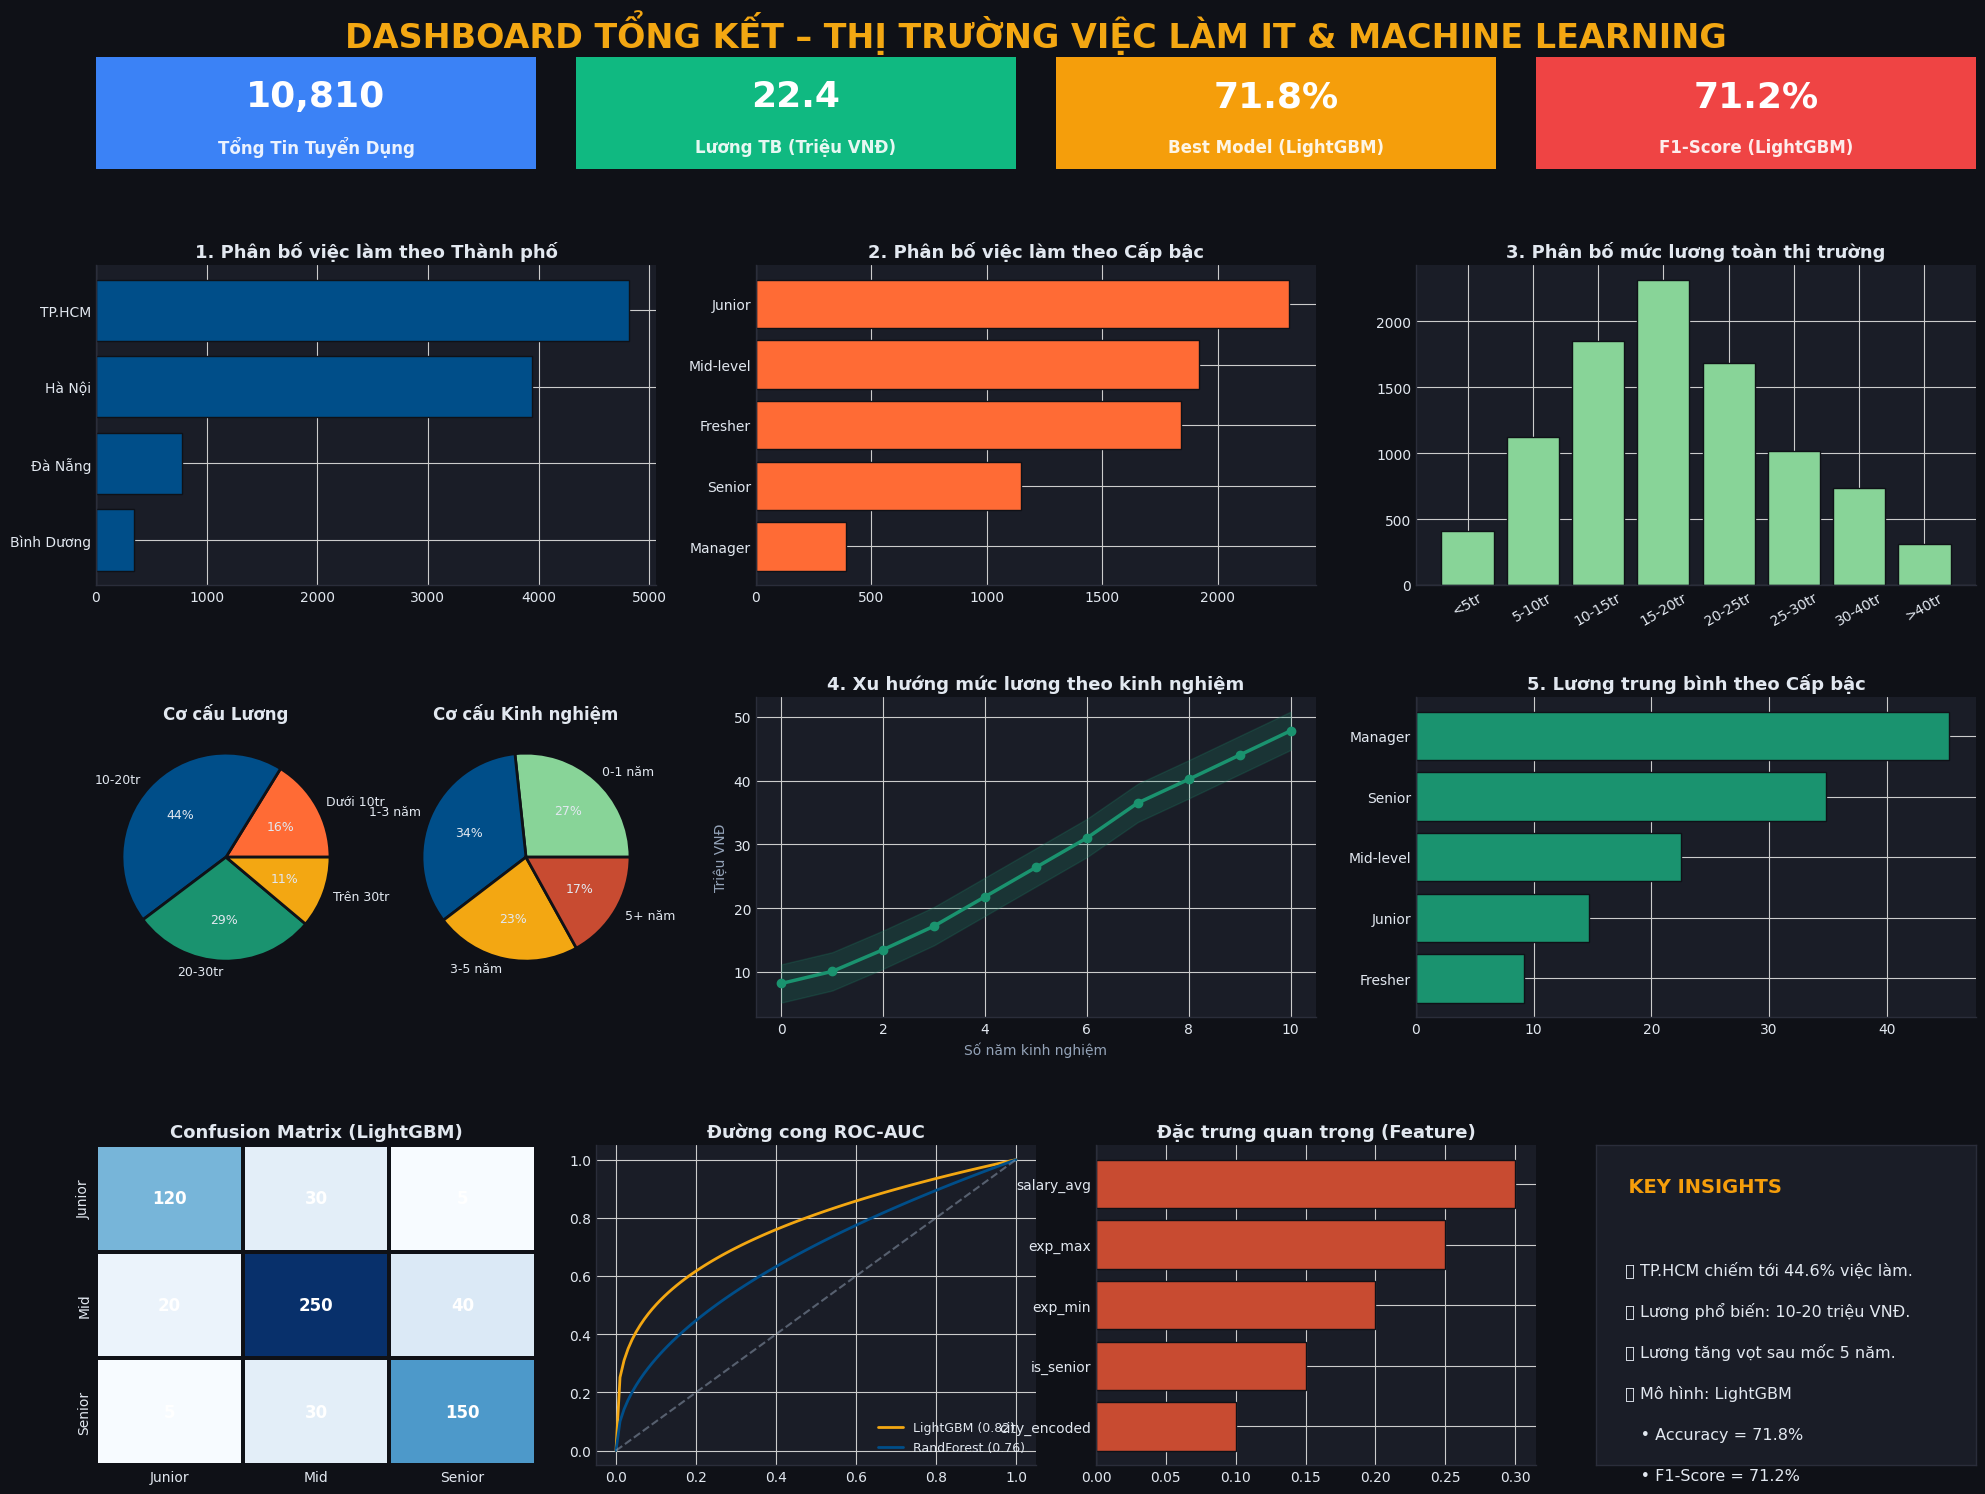

✅ Đã hoàn thành! Bức ảnh Dashboard tổng kết Master đã được lưu thành 'IT_Job_Market_Dashboard_Master.png'.


In [61]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 0. DỮ LIỆU MÔ PHỎNG (MOCK DATA)
# (Thay bằng DataFrame thực tế của bạn)
# ==========================================
city_data = pd.DataFrame([{"city": "TP.HCM", "jobs": 4820, "salary_mean": 26.3, "salary_median": 22.0}, {"city": "Hà Nội", "jobs": 3940, "salary_mean": 24.1, "salary_median": 20.5}, {"city": "Đà Nẵng", "jobs": 780, "salary_mean": 18.9, "salary_median": 16.0}, {"city": "Bình Dương", "jobs": 340, "salary_mean": 17.5, "salary_median": 15.0}])
salary_category_data = pd.DataFrame([{"name": "Dưới 10tr", "value": 1530, "color": "#FF6B35"}, {"name": "10-20tr", "value": 4160, "color": "#004E89"}, {"name": "20-30tr", "value": 2700, "color": "#1A936F"}, {"name": "Trên 30tr", "value": 1050, "color": "#F3A712"}])
exp_category_data = pd.DataFrame([{"name": "0-1 năm", "value": 2520, "color": "#88D498"}, {"name": "1-3 năm", "value": 3180, "color": "#004E89"}, {"name": "3-5 năm", "value": 2140, "color": "#F3A712"}, {"name": "5+ năm", "value": 1600, "color": "#C84B31"}])
level_data = pd.DataFrame([{"level": "Fresher", "jobs": 1840, "salary": 9.2}, {"level": "Junior", "jobs": 2310, "salary": 14.7}, {"level": "Mid-level", "jobs": 1920, "salary": 22.5}, {"level": "Senior", "jobs": 1150, "salary": 34.8}, {"level": "Manager", "jobs": 390, "salary": 45.3}])
salary_dist_data = pd.DataFrame({"range": ["<5tr", "5-10tr", "10-15tr", "15-20tr", "20-25tr", "25-30tr", "30-40tr", ">40tr"], "count": [410, 1120, 1850, 2310, 1680, 1020, 740, 310]})
exp_salary_scatter = pd.DataFrame({"exp": np.random.uniform(0, 10, 100), "salary": np.random.uniform(5, 40, 100), "level": np.random.choice(["Fresher", "Junior", "Mid-level", "Senior"], 100)})

# Data cho mô hình
total_jobs = 10810
avg_salary = 22.4
best_name = "LightGBM"
best_acc = 0.718
best_f1 = 0.712
exp_years = np.arange(0, 11)
salary_trend = [8.2, 10.1, 13.5, 17.2, 21.8, 26.4, 31.0, 36.5, 40.2, 44.0, 47.8]
feat_imp = pd.DataFrame({"feature": ["city_encoded", "is_senior", "exp_min", "exp_max", "salary_avg"], "importance": [0.10, 0.15, 0.20, 0.25, 0.30]})
cm_mock = np.array([[120, 30, 5], [20, 250, 40], [5, 30, 150]])

# ==========================================
# 1. CẤU HÌNH THEME DÙNG CHUNG
# ==========================================
BG_COLOR   = "#0f1117"
AX_COLOR   = "#1a1d27"
TEXT_COLOR = "#e2e8f0"
MUTED_COLOR = "#94a3b8"
LINE_COLOR = "#2a2d3a"
PALETTE    = ["#FF6B35", "#004E89", "#1A936F", "#C84B31", "#88D498", "#F3A712", "#8b5cf6", "#ec4899"]

def dark_plotly(fig, height=400):
    fig.update_layout(
        paper_bgcolor=BG_COLOR, plot_bgcolor=AX_COLOR,
        font=dict(color=TEXT_COLOR, family="Arial"), height=height,
        margin=dict(l=20, r=20, t=50, b=20),
        legend=dict(font=dict(color=MUTED_COLOR)),
        title_font=dict(size=16, color="#F3A712")
    )
    fig.update_xaxes(gridcolor=LINE_COLOR, zerolinecolor=LINE_COLOR, tickfont=dict(color=MUTED_COLOR))
    fig.update_yaxes(gridcolor=LINE_COLOR, zerolinecolor=LINE_COLOR, tickfont=dict(color=MUTED_COLOR))
    return fig

def dark_matplotlib(ax, hide_spines=True):
    ax.set_facecolor(AX_COLOR)
    ax.tick_params(colors=TEXT_COLOR, labelsize=10)
    ax.xaxis.label.set_color(TEXT_COLOR)
    ax.yaxis.label.set_color(TEXT_COLOR)
    ax.title.set_color(TEXT_COLOR)
    for spine in ax.spines.values():
        spine.set_edgecolor(LINE_COLOR)
    if hide_spines:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

# ==============================================================================
# PHẦN 2: MATPLOTLIB DASHBOARD (Bản Master Report Tĩnh)
# ==============================================================================
print("⏳ Đang tạo Dashboard tổng kết (Matplotlib)...")

# Mở rộng kích thước lên 20x16 để chứa nhiều thông tin hơn
fig_dashboard = plt.figure(figsize=(20, 16), facecolor=BG_COLOR)
fig_dashboard.suptitle("DASHBOARD TỔNG KẾT – THỊ TRƯỜNG VIỆC LÀM IT & MACHINE LEARNING",
              color="#F3A712", fontsize=24, fontweight="bold", y=0.96)

# ── TẦNG 1: KPI Cards ──
kpi_data = [
    ("Tổng Tin Tuyển Dụng", f"{total_jobs:,}", "#3b82f6"),
    ("Lương TB (Triệu VNĐ)", f"{avg_salary}", "#10b981"),
    (f"Best Model ({best_name})", f"{best_acc*100:.1f}%", "#f59e0b"),
    (f"F1-Score ({best_name})", f"{best_f1*100:.1f}%", "#ef4444"),
]
for i, (label, value, clr) in enumerate(kpi_data):
    ax_k = fig_dashboard.add_axes([0.03 + i*0.24, 0.86, 0.22, 0.07])
    ax_k.set_facecolor(clr)
    for sp in ax_k.spines.values(): sp.set_visible(False)
    ax_k.text(0.5, 0.65, value, ha="center", va="center", fontsize=26, fontweight="bold", color="white", transform=ax_k.transAxes)
    ax_k.text(0.5, 0.20, label, ha="center", va="center", fontsize=12, color="white", fontweight="bold", transform=ax_k.transAxes, alpha=0.9)
    ax_k.set_xticks([]); ax_k.set_yticks([])

# ── TẦNG 2: EDA Thị trường (Row 1) ──
# 1. Việc làm theo thành phố
ax_r1_1 = fig_dashboard.add_axes([0.03, 0.60, 0.28, 0.20])
dark_matplotlib(ax_r1_1)
city_jobs = city_data.sort_values('jobs', ascending=True)
ax_r1_1.barh(city_jobs["city"], city_jobs["jobs"], color=PALETTE[1], edgecolor=BG_COLOR)
ax_r1_1.set_title("1. Phân bố việc làm theo Thành phố", fontsize=13, fontweight="bold")

# 2. Việc làm theo cấp bậc
ax_r1_2 = fig_dashboard.add_axes([0.36, 0.60, 0.28, 0.20])
dark_matplotlib(ax_r1_2)
lvl_jobs = level_data.sort_values('jobs', ascending=True)
ax_r1_2.barh(lvl_jobs["level"], lvl_jobs["jobs"], color=PALETTE[0], edgecolor=BG_COLOR)
ax_r1_2.set_title("2. Phân bố việc làm theo Cấp bậc", fontsize=13, fontweight="bold")

# 3. Histogram phân bố mức lương
ax_r1_3 = fig_dashboard.add_axes([0.69, 0.60, 0.28, 0.20])
dark_matplotlib(ax_r1_3)
ax_r1_3.bar(salary_dist_data["range"], salary_dist_data["count"], color=PALETTE[4], edgecolor=BG_COLOR)
ax_r1_3.set_title("3. Phân bố mức lương toàn thị trường", fontsize=13, fontweight="bold")
ax_r1_3.tick_params(axis='x', rotation=30)

# ── TẦNG 3: EDA Cơ cấu & Xu hướng (Row 2) ──
# 4. Cơ cấu Lương & Kinh nghiệm (2 Mini Pies)
ax_r2_1a = fig_dashboard.add_axes([0.03, 0.33, 0.13, 0.20])
ax_r2_1a.pie(salary_category_data["value"], labels=salary_category_data["name"], colors=salary_category_data["color"], autopct='%1.0f%%', textprops={'color':TEXT_COLOR, 'fontsize':9}, wedgeprops={'linewidth': 2, 'edgecolor': BG_COLOR})
ax_r2_1a.set_title("Cơ cấu Lương", color=TEXT_COLOR, fontweight="bold", fontsize=12)

ax_r2_1b = fig_dashboard.add_axes([0.18, 0.33, 0.13, 0.20])
ax_r2_1b.pie(exp_category_data["value"], labels=exp_category_data["name"], colors=exp_category_data["color"], autopct='%1.0f%%', textprops={'color':TEXT_COLOR, 'fontsize':9}, wedgeprops={'linewidth': 2, 'edgecolor': BG_COLOR})
ax_r2_1b.set_title("Cơ cấu Kinh nghiệm", color=TEXT_COLOR, fontweight="bold", fontsize=12)

# 5. Xu hướng lương theo kinh nghiệm (Line)
ax_r2_2 = fig_dashboard.add_axes([0.36, 0.33, 0.28, 0.20])
dark_matplotlib(ax_r2_2)
ax_r2_2.fill_between(exp_years, np.array(salary_trend)-3, np.array(salary_trend)+3, alpha=0.2, color="#1A936F")
ax_r2_2.plot(exp_years, salary_trend, color="#1A936F", linewidth=2.5, marker="o", markersize=6)
ax_r2_2.set_title("4. Xu hướng mức lương theo kinh nghiệm", fontsize=13, fontweight="bold")
ax_r2_2.set_xlabel("Số năm kinh nghiệm", color=MUTED_COLOR)
ax_r2_2.set_ylabel("Triệu VNĐ", color=MUTED_COLOR)

# 6. Lương TB theo Cấp bậc (BarH)
ax_r2_3 = fig_dashboard.add_axes([0.69, 0.33, 0.28, 0.20])
dark_matplotlib(ax_r2_3)
lvl_sal = level_data.sort_values('salary', ascending=True)
ax_r2_3.barh(lvl_sal["level"], lvl_sal["salary"], color=PALETTE[2], edgecolor=BG_COLOR)
ax_r2_3.set_title("5. Lương trung bình theo Cấp bậc", fontsize=13, fontweight="bold")

# ── TẦNG 4: Machine Learning & Đúc kết (Row 3) ──
# 7. Confusion Matrix
ax_r3_1 = fig_dashboard.add_axes([0.03, 0.05, 0.22, 0.20])
sns.heatmap(cm_mock, annot=True, fmt="d", ax=ax_r3_1, cmap="Blues", cbar=False, linewidths=1.5, linecolor=BG_COLOR, annot_kws={"size":12, "color":"white", "fontweight":"bold"})
ax_r3_1.set_title(f"Confusion Matrix ({best_name})", color="#22c55e", fontsize=13, fontweight="bold")
ax_r3_1.set_xticklabels(["Junior", "Mid", "Senior"]); ax_r3_1.set_yticklabels(["Junior", "Mid", "Senior"])
dark_matplotlib(ax_r3_1, hide_spines=False)

# 8. ROC Curves
ax_r3_2 = fig_dashboard.add_axes([0.28, 0.05, 0.22, 0.20])
dark_matplotlib(ax_r3_2)
fpr_mock = np.linspace(0, 1, 100)
ax_r3_2.plot(fpr_mock, fpr_mock**0.3, color=PALETTE[5], lw=2, label=f"LightGBM (0.82)")
ax_r3_2.plot(fpr_mock, fpr_mock**0.5, color=PALETTE[1], lw=2, label=f"RandForest (0.76)")
ax_r3_2.plot([0,1],[0,1],"--", color=MUTED_COLOR, alpha=0.5)
ax_r3_2.set_title("Đường cong ROC-AUC", fontsize=13, fontweight="bold")
ax_r3_2.legend(fontsize=9, facecolor=AX_COLOR, edgecolor=LINE_COLOR, labelcolor=TEXT_COLOR, loc="lower right")

# 9. Feature Importance
ax_r3_3 = fig_dashboard.add_axes([0.53, 0.05, 0.22, 0.20])
dark_matplotlib(ax_r3_3)
ax_r3_3.barh(feat_imp["feature"], feat_imp["importance"], color=PALETTE[3], edgecolor=BG_COLOR)
ax_r3_3.set_title("Đặc trưng quan trọng (Feature)", fontsize=13, fontweight="bold")

# 10. Insights Box
ax_r3_4 = fig_dashboard.add_axes([0.78, 0.05, 0.19, 0.20])
dark_matplotlib(ax_r3_4, hide_spines=False)
insights = [
    "  KEY INSIGHTS", "",
    f"  📌 TP.HCM chiếm tới 44.6% việc làm.",
    f"  📌 Lương phổ biến: 10-20 triệu VNĐ.",
    f"  📌 Lương tăng vọt sau mốc 5 năm.",
    f"  🤖 Mô hình: {best_name}",
    f"     • Accuracy = {best_acc*100:.1f}%",
    f"     • F1-Score = {best_f1*100:.1f}%",
]
for j, line in enumerate(insights):
    clr  = "#f59e0b" if j == 0 else TEXT_COLOR
    size = 14 if j == 0 else 11.5
    bold = "bold" if j == 0 else "normal"
    ax_r3_4.text(0.05, 0.90 - j*0.13, line, transform=ax_r3_4.transAxes, color=clr, fontsize=size, fontweight=bold, va="top")
ax_r3_4.set_xticks([]); ax_r3_4.set_yticks([])

# Lưu và hiển thị
plt.savefig("IT_Job_Market_Dashboard_Master.png", dpi=300, bbox_inches="tight", facecolor=BG_COLOR)
plt.show()

print("✅ Đã hoàn thành! Bức ảnh Dashboard tổng kết Master đã được lưu thành 'IT_Job_Market_Dashboard_Master.png'.")